In [4]:
import pandas as pd
from pathlib import Path

In [5]:
DATA_PATH = Path("data")

VISIT_PATH = DATA_PATH / "visit"
TRAVEL_PATH = DATA_PATH / "travel"
TRAVELER_PATH = DATA_PATH / "traveler"

# 1. 데이터 병합

## 1-1. 방문지 데이터 병합

In [6]:
import re

VISIT_PATH = Path("data/visit")

region_map = {
    "B": "동부권",
    "C": "서부권",
    "E": "수도권",
    "H": "남부권"
}

visit_files = sorted(VISIT_PATH.glob("*.csv"))

visit_list = []

for file in visit_files:

    match = re.search(
        r"_([BCEH])(?:\(\d+\))?$",
        file.stem.upper()
    )

    if match is None:
        raise ValueError(
            f"파일명에서 권역 코드를 찾지 못했습니다: {file.name}"
        )

    region_code = match.group(1)

    df = pd.read_csv(
        file,
        low_memory=False
    )

    # 파일이 어느 권역에서 왔는지 기록
    df["REGION_CODE"] = region_code
    df["REGION"] = region_map[region_code]
    df["SOURCE_FILE"] = file.name

    visit_list.append(df)

visit_all = pd.concat(
    visit_list,
    ignore_index=True
)

visit_all

,VISIT_AREA_ID,TRAVEL_ID,VISIT_ORDER,VISIT_AREA_NM,VISIT_START_YMD,VISIT_END_YMD,ROAD_NM_ADDR,LOTNO_ADDR,X_COORD,Y_COORD,...,REVISIT_YN,VISIT_CHC_REASON_CD,LODGING_TYPE_CD,DGSTFN,REVISIT_INTENTION,RCMDTN_INTENTION,SGG_CD,REGION_CODE,REGION,SOURCE_FILE
0,2209040011,b_b001138,7,광안리해수욕장,2022-09-04,2022-09-04,부산 수영구 광안해변로 219,부산 수영구 광안동 192-20,129.1189761,35.15319327,...,N,1.0,NaN,4.0,4.0,4.0,NaN,B,동부권,tn_visit_area_info_방문지정보_B.csv
1,2208200002,b_b000246,2,김포국제공항 국내선,2022-08-20,2022-08-20,서울 강서구 하늘길 112,서울 강서구 공항동 1373,126.8028655,37.55894903,...,Y,6.0,NaN,5.0,5.0,5.0,NaN,B,동부권,tn_visit_area_info_방문지정보_B.csv
2,2209250005,b_b004595,11,여주휴게소주유소 인천방향,2022-09-25,2022-09-25,경기 여주시 가남읍 화평길 116,경기 여주시 가남읍 본두리 677-1,127.5687835,37.23973935,...,Y,11.0,NaN,4.0,4.0,4.0,NaN,B,동부권,tn_visit_area_info_방문지정보_B.csv
3,2210040003,b_b005102,13,감자바우옹심이칼국수,2022-10-04,2022-10-04,강원 영월군 영월읍 중앙로 183-1,강원 영월군 영월읍 덕포리 632-64,128.4776642,37.17597129,...,N,2.0,NaN,5.0,5.0,5.0,NaN,B,동부권,tn_visit_area_info_방문지정보_B.csv
4,2209270005,b_b005081,16,속초고속버스터미널,2022-09-27,2022-09-27,강원 속초시 동해대로 3988,강원 속초시 조양동 1418,128.598776,38.1904606,...,Y,6.0,NaN,5.0,5.0,5.0,NaN,B,동부권,tn_visit_area_info_방문지정보_B.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139157,2309220002,h_h006874,2,꼬스뗀뇨,2023-09-22,2023-09-22,제주특별자치도 제주시 구좌읍 해맞이해안로 2080,제주특별자치도 제주시 구좌읍 종달리 150,126.905244,33.509868,...,N,1.0,NaN,3.0,2.0,2.0,NaN,H,남부권,tn_visit_area_info_방문지정보_H.csv
139158,2309220003,h_h006874,3,마이 피기 팬트리,2023-09-22,2023-09-22,제주특별자치도 제주시 구좌읍 하도13길 6,제주특별자치도 제주시 구좌읍 하도리 1091-5,126.888132,33.5087,...,N,2.0,NaN,4.0,4.0,4.0,NaN,H,남부권,tn_visit_area_info_방문지정보_H.csv
139159,2309220004,h_h006874,4,월정리 해수욕장,2023-09-22,2023-09-22,NaN,제주특별자치도 제주시 구좌읍 월정리 33-3,126.795805,33.556469,...,Y,11.0,NaN,4.0,4.0,4.0,NaN,H,남부권,tn_visit_area_info_방문지정보_H.csv
139160,2309220005,h_h006874,5,민경이네어등포해녀촌,2023-09-22,2023-09-22,제주특별자치도 제주시 구좌읍 해맞이해안로 830,제주특별자치도 제주시 구좌읍 행원리 102,126.825773,33.553735,...,N,2.0,NaN,4.0,4.0,4.0,NaN,H,남부권,tn_visit_area_info_방문지정보_H.csv


In [7]:
visit_all["REGION"].value_counts(dropna=False)

REGION
남부권    46009
동부권    36984
서부권    34785
수도권    21384
Name: count, dtype: int64

## 1-2. 여행 데이터 병합

In [8]:
TRAVEL_PATH = Path("data/travel")

travel_files = sorted(TRAVEL_PATH.glob("*.csv"))

travel_list = []

for file in travel_files:

    match = re.search(
        r"_([BCEH])(?:\(\d+\))?$",
        file.stem.upper()
    )

    if match is None:
        raise ValueError(
            f"파일명에서 권역 코드를 찾지 못했습니다: {file.name}"
        )

    region_code = match.group(1)

    df = pd.read_csv(
        file,
        low_memory=False
    )

    df["REGION_CODE"] = region_code
    df["REGION"] = region_map[region_code]
    df["SOURCE_FILE"] = file.name

    travel_list.append(df)

travel_all = pd.concat(
    travel_list,
    ignore_index=True
)

travel_all

,TRAVEL_ID,TRAVEL_NM,TRAVELER_ID,TRAVEL_PURPOSE,TRAVEL_START_YMD,TRAVEL_END_YMD,MVMN_NM,TRAVEL_PERSONA,TRAVEL_MISSION,TRAVEL_MISSION_CHECK,REGION_CODE,REGION,SOURCE_FILE
0,b_b015715,B04,b015715,22;,2022-10-29,2022-10-30,대중교통 등,NaN,22;,22;4;1,B,동부권,tn_travel_여행_B.csv
1,b_b000419,B01,b000419,21;,2022-08-06,2022-08-08,자가용,NaN,2;,21;11;5,B,동부권,tn_travel_여행_B.csv
2,b_b013638,B01,b013638,28;,2022-11-05,2022-11-06,NaN,NaN,28;,3;6;21,B,동부권,tn_travel_여행_B.csv
3,b_b007836,B02,b007836,13;24;26;3;4;,2022-10-18,2022-10-19,대중교통 등,NaN,13;24;26;3;4;,26;6;3,B,동부권,tn_travel_여행_B.csv
4,b_b004718,B04,b004718,1;26;6;9;,2022-10-01,2022-10-03,대중교통 등,경상권에 거주하는 39세 이하 커플,1;26;6;9;,9;6;1,B,동부권,tn_travel_여행_B.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11515,h_h006755,H01,h006755,12;22;26;3;5,2023-09-20,2023-09-21,NaN,"제주,도서지역 방문/거주지 구분 없음/39세 이하/커플/일반미션",12;22;26;3;5,22;26;3,H,남부권,tn_travel_여행_H.csv
11516,h_h006766,H01,h006766,6;22;24;26;2,2023-09-21,2023-09-22,NaN,"제주,도서지역 방문/거주지 구분 없음/40세 이상/커플/일반미션",6;22;24;26;2,6;9;22,H,남부권,tn_travel_여행_H.csv
11517,h_h006870,H01,h006870,1;4,2023-09-23,2023-09-24,NaN,"제주,도서지역 방문/거주지 구분 없음/40세 이상/자녀동반/일반미션",1;4,6;22;5,H,남부권,tn_travel_여행_H.csv
11518,h_h006872,H01,h006872,9;3,2023-09-23,2023-09-24,NaN,"제주,도서지역 방문/거주지 구분 없음/39세 이하/3인 이상 친구/일반미션",9;3,11;9;3,H,남부권,tn_travel_여행_H.csv


In [9]:
travel_all["REGION"].value_counts(dropna=False)

REGION
동부권    3200
서부권    3200
수도권    2560
남부권    2560
Name: count, dtype: int64

## 1-3. 여행자 데이터 병합

In [10]:
traveler_files = sorted(TRAVELER_PATH.glob("*.csv"))

traveler_list = []

for file in traveler_files:

    print(file.name)

    df = pd.read_csv(file)

    traveler_list.append(df)

traveler_all = pd.concat(
    traveler_list,
    ignore_index=True
)

traveler_all

tn_traveller_master_여행객 Master_B.csv
tn_traveller_master_여행객 Master_C.csv
tn_traveller_master_여행객 Master_E.csv
tn_traveller_master_여행객 Master_H.csv


,TRAVELER_ID,RESIDENCE_SGG_CD,GENDER,AGE_GRP,EDU_NM,EDU_FNSH_SE,MARR_STTS,FAMILY_MEMB,JOB_NM,JOB_ETC,...,TRAVEL_STYL_7,TRAVEL_STYL_8,TRAVEL_STATUS_RESIDENCE,TRAVEL_STATUS_DESTINATION,TRAVEL_STATUS_ACCOMPANY,TRAVEL_STATUS_YMD,TRAVEL_MOTIVE_1,TRAVEL_MOTIVE_2,TRAVEL_MOTIVE_3,TRAVEL_COMPANIONS_NUM
0,b009514,31,여,20,6,1.0,1,3,3.0,NaN,...,2,4,울산광역시,경남,2인 여행(가족 외),2022-10-30~2022-10-30,6.0,2.0,NaN,1
1,b015795,29,여,30,6,1.0,1,1,3.0,NaN,...,6,6,광주광역시,대구,나홀로 여행,2022-10-29~2022-10-29,8.0,2.0,1.0,0
2,b004208,31,여,20,6,1.0,1,4,2.0,NaN,...,6,5,울산광역시,경북,2인 여행(가족 외),2022-09-24~2022-09-25,3.0,7.0,5.0,1
3,b006840,11,여,30,6,1.0,1,4,3.0,NaN,...,1,7,서울특별시,강원,나홀로 여행,2022-10-05~2022-10-05,5.0,7.0,1.0,1
4,b002386,26,남,40,4,1.0,2,4,5.0,NaN,...,7,7,부산광역시,울산,자녀 동반 여행,2022-08-22~2022-08-23,3.0,7.0,2.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11515,f004009,27,여,30,6,1.0,1,1,4.0,NaN,...,3,4,대구광역시,경북,2인 여행(가족 외),2023-07-09~2023-07-10,2.0,1.0,7.0,1
11516,g002531,41,여,40,6,1.0,2,4,11.0,NaN,...,1,5,경기도,충남,자녀 동반 여행,2023-06-11~2023-06-12,2.0,3.0,9.0,4
11517,e002496,30,여,50,6,1.0,2,2,3.0,NaN,...,2,4,대전광역시,서울,부모 동반 여행,2023-06-10~2023-06-11,8.0,3.0,1.0,5
11518,h003082,11,남,20,6,2.0,1,1,3.0,NaN,...,2,7,서울특별시,제주,2인 여행(가족 외),2023-08-13~2023-08-16,3.0,4.0,1.0,1


## 1-4. 중복 확인 및 저장

In [11]:
print("visit :", visit_all.duplicated().sum())

print("travel :", travel_all.duplicated().sum())

print("traveler :", traveler_all.duplicated().sum())

visit : 0
travel : 0
traveler : 0


In [12]:
OUTPUT = Path("data")

visit_all.to_csv(
    OUTPUT / "visit_all.csv",
    index=False,
    encoding="utf-8-sig"
)

travel_all.to_csv(
    OUTPUT / "travel_all.csv",
    index=False,
    encoding="utf-8-sig"
)

traveler_all.to_csv(
    OUTPUT / "traveler_all.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료!")

저장 완료!


# 2. 방문지 유형 재분류

체험: 1, 2, 3, 5, 6, 7, 8, 13
식도락: 11
쇼핑: 4, 10
나머지: 분석 대상 제외

In [13]:
visit_all["VISIT_AREA_TYPE_CD"] = (
    visit_all["VISIT_AREA_TYPE_CD"]
    .astype("string")
    .str.strip()
    .str.replace(".0", "", regex=False)
)

visit_all["VISIT_AREA_TYPE_CD"].value_counts().sort_index()

VISIT_AREA_TYPE_CD
1     12784
10     4230
11    35447
12     2156
13     3038
2      6932
21    20627
22     3621
23      774
24    13690
3      3371
4      9119
5      1461
6      2853
7      3713
8       851
9     14495
Name: count, dtype: Int64

In [14]:
experience_codes = {
    "1", "2", "3", "5", "6", "7", "8", "13"
}

food_codes = {
    "11"
}

shopping_codes = {
    "4", "10"
}


def classify_visit_type(code):
    if pd.isna(code):
        return pd.NA

    code = str(code).strip()

    if code in experience_codes:
        return "체험"

    if code in food_codes:
        return "식도락"

    if code in shopping_codes:
        return "쇼핑"

    return pd.NA

In [15]:
visit_all["ACTIVITY_TYPE"] = (
    visit_all["VISIT_AREA_TYPE_CD"]
    .apply(classify_visit_type)
)

visit_all[
    ["VISIT_AREA_TYPE_CD", "ACTIVITY_TYPE"]
].drop_duplicates().sort_values("VISIT_AREA_TYPE_CD")

,VISIT_AREA_TYPE_CD,ACTIVITY_TYPE
0,1,체험
15,10,쇼핑
3,11,식도락
38,12,NaN
74,13,체험
9,2,체험
16,21,NaN
53,22,NaN
461,23,NaN
22,24,NaN


In [16]:
visit_all["ACTIVITY_TYPE"].value_counts(dropna=False)

ACTIVITY_TYPE
NaN    55363
식도락    35447
체험     35003
쇼핑     13349
Name: count, dtype: int64

# 3. 분석 대상 방문지 필터링

In [17]:
activity_visit = visit_all[
    visit_all["ACTIVITY_TYPE"].notna()
].copy()

print("전체 방문 기록 수:", len(visit_all))
print("분석 대상 방문 기록 수:", len(activity_visit))

activity_visit.head()

전체 방문 기록 수: 139162
분석 대상 방문 기록 수: 83799


,VISIT_AREA_ID,TRAVEL_ID,VISIT_ORDER,VISIT_AREA_NM,VISIT_START_YMD,VISIT_END_YMD,ROAD_NM_ADDR,LOTNO_ADDR,X_COORD,Y_COORD,...,VISIT_CHC_REASON_CD,LODGING_TYPE_CD,DGSTFN,REVISIT_INTENTION,RCMDTN_INTENTION,SGG_CD,REGION_CODE,REGION,SOURCE_FILE,ACTIVITY_TYPE
0,2209040011,b_b001138,7,광안리해수욕장,2022-09-04,2022-09-04,부산 수영구 광안해변로 219,부산 수영구 광안동 192-20,129.1189761,35.15319327,...,1.0,NaN,4.0,4.0,4.0,NaN,B,동부권,tn_visit_area_info_방문지정보_B.csv,체험
3,2210040003,b_b005102,13,감자바우옹심이칼국수,2022-10-04,2022-10-04,강원 영월군 영월읍 중앙로 183-1,강원 영월군 영월읍 덕포리 632-64,128.4776642,37.17597129,...,2.0,NaN,5.0,5.0,5.0,NaN,B,동부권,tn_visit_area_info_방문지정보_B.csv,식도락
6,2210080004,b_b005770,3,문막교,2022-10-08,2022-10-08,NaN,강원 원주시 문막읍 취병리,127.8090951,37.30759338,...,2.0,NaN,4.0,3.0,4.0,NaN,B,동부권,tn_visit_area_info_방문지정보_B.csv,체험
7,2210300003,b_b014501,2,이케아 동부산점,2022-10-30,2022-10-30,동부산관광3로 17,NaN,129.2104793,35.19079654,...,1.0,NaN,5.0,5.0,5.0,26710.0,B,동부권,tn_visit_area_info_방문지정보_B.csv,쇼핑
9,2211050008,b_b009366,5,호우총,2022-11-05,2022-11-05,NaN,경북 경주시 노서동 215,129.2090453,35.83972069,...,9.0,NaN,4.0,4.0,4.0,NaN,B,동부권,tn_visit_area_info_방문지정보_B.csv,체험


In [18]:
activity_ratio = len(activity_visit) / len(visit_all)

print(f"분석 대상 방문 기록 비율: {activity_ratio:.2%}")

분석 대상 방문 기록 비율: 60.22%


# 4. 방문지 유형별 방문비율
## 4-1. 유형별 방문 횟수 집계

In [19]:
visit_count = (
    activity_visit
    .groupby(
        ["TRAVEL_ID", "REGION", "ACTIVITY_TYPE"]
    )
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

visit_count.head()

ACTIVITY_TYPE,TRAVEL_ID,REGION,쇼핑,식도락,체험
0,a_a000155,동부권,1,2,5
1,a_a000193,동부권,1,6,3
2,a_a000202,서부권,0,1,3
3,a_a000273,서부권,0,2,1
4,a_a000316,동부권,1,6,6


In [20]:
for column in ["체험", "식도락", "쇼핑"]:
    if column not in visit_count.columns:
        visit_count[column] = 0

visit_count = visit_count[
    ["TRAVEL_ID", "REGION", "체험", "식도락", "쇼핑"]
]

visit_count.head()

ACTIVITY_TYPE,TRAVEL_ID,REGION,체험,식도락,쇼핑
0,a_a000155,동부권,5,2,1
1,a_a000193,동부권,3,6,1
2,a_a000202,서부권,3,1,0
3,a_a000273,서부권,1,2,0
4,a_a000316,동부권,6,6,1


In [21]:
visit_count = visit_count.rename(
    columns={
        "체험": "체험_방문수",
        "식도락": "식도락_방문수",
        "쇼핑": "쇼핑_방문수"
    }
)

visit_count.head()

ACTIVITY_TYPE,TRAVEL_ID,REGION,체험_방문수,식도락_방문수,쇼핑_방문수
0,a_a000155,동부권,5,2,1
1,a_a000193,동부권,3,6,1
2,a_a000202,서부권,3,1,0
3,a_a000273,서부권,1,2,0
4,a_a000316,동부권,6,6,1


## 4-2. 여행별 방문비율 생성

In [22]:
visit_count["활동_방문수"] = (
    visit_count["체험_방문수"]
    + visit_count["식도락_방문수"]
    + visit_count["쇼핑_방문수"]
)

visit_count[
    [
        "TRAVEL_ID",
        "체험_방문수",
        "식도락_방문수",
        "쇼핑_방문수",
        "활동_방문수"
    ]
].head()

ACTIVITY_TYPE,TRAVEL_ID,체험_방문수,식도락_방문수,쇼핑_방문수,활동_방문수
0,a_a000155,5,2,1,8
1,a_a000193,3,6,1,10
2,a_a000202,3,1,0,4
3,a_a000273,1,2,0,3
4,a_a000316,6,6,1,13


In [23]:
visit_count["체험_방문비율"] = (
    visit_count["체험_방문수"]
    / visit_count["활동_방문수"]
)

visit_count["식도락_방문비율"] = (
    visit_count["식도락_방문수"]
    / visit_count["활동_방문수"]
)

visit_count["쇼핑_방문비율"] = (
    visit_count["쇼핑_방문수"]
    / visit_count["활동_방문수"]
)

visit_count.head()

ACTIVITY_TYPE,TRAVEL_ID,REGION,체험_방문수,식도락_방문수,쇼핑_방문수,활동_방문수,체험_방문비율,식도락_방문비율,쇼핑_방문비율
0,a_a000155,동부권,5,2,1,8,0.625000,0.250000,0.125000
1,a_a000193,동부권,3,6,1,10,0.300000,0.600000,0.100000
2,a_a000202,서부권,3,1,0,4,0.750000,0.250000,0.000000
3,a_a000273,서부권,1,2,0,3,0.333333,0.666667,0.000000
4,a_a000316,동부권,6,6,1,13,0.461538,0.461538,0.076923


In [24]:
visit_count["비율합계"] = (
    visit_count["체험_방문비율"]
    + visit_count["식도락_방문비율"]
    + visit_count["쇼핑_방문비율"]
)

visit_count["비율합계"].describe()

count    1.301100e+04
mean     1.000000e+00
std      2.834455e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: 비율합계, dtype: float64

In [25]:
import numpy as np

invalid_ratio = visit_count[
    ~np.isclose(
        visit_count["비율합계"],
        1.0
    )
]

print("비율합계가 1이 아닌 여행 수:", len(invalid_ratio))

invalid_ratio.head()

비율합계가 1이 아닌 여행 수: 0


ACTIVITY_TYPE,TRAVEL_ID,REGION,체험_방문수,식도락_방문수,쇼핑_방문수,활동_방문수,체험_방문비율,식도락_방문비율,쇼핑_방문비율,비율합계


# 5. 모델 입력 데이터 구성
## 5-1. 분석 변수 지정

In [26]:
feature_columns = [
    "체험_방문비율",
    "식도락_방문비율",
    "쇼핑_방문비율"
]

X = visit_count[feature_columns].copy()

X.head()

ACTIVITY_TYPE,체험_방문비율,식도락_방문비율,쇼핑_방문비율
0,0.625000,0.250000,0.125000
1,0.300000,0.600000,0.100000
2,0.750000,0.250000,0.000000
3,0.333333,0.666667,0.000000
4,0.461538,0.461538,0.076923


## 5-2. 결측치 및 무한값 확인

In [27]:
print("결측치")
display(X.isna().sum())

print("무한값 개수")
print(np.isinf(X.to_numpy()).sum())

결측치


ACTIVITY_TYPE
체험_방문비율     0
식도락_방문비율    0
쇼핑_방문비율     0
dtype: int64

무한값 개수
0


In [28]:
X.describe()

ACTIVITY_TYPE,체험_방문비율,식도락_방문비율,쇼핑_방문비율
count,13011.000000,13011.000000,13011.000000
mean,0.435849,0.409282,0.154869
std,0.245074,0.233019,0.194938
min,0.000000,0.000000,0.000000
25%,0.285714,0.250000,0.000000
50%,0.428571,0.416667,0.100000
75%,0.571429,0.538462,0.250000
max,1.000000,1.000000,1.000000


In [29]:
X_model = X.copy()

X_model.head()

ACTIVITY_TYPE,체험_방문비율,식도락_방문비율,쇼핑_방문비율
0,0.625000,0.250000,0.125000
1,0.300000,0.600000,0.100000
2,0.750000,0.250000,0.000000
3,0.333333,0.666667,0.000000
4,0.461538,0.461538,0.076923


# 6. PCA

In [30]:
from sklearn.decomposition import PCA

In [31]:
pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_model)

pca_result[:5]

array([[ 0.24902979, -0.00500714],
       [-0.22051809, -0.09597299],
       [ 0.3561388 , -0.14564022],
       [-0.22834892, -0.22044883],
       [-0.00651435, -0.09707654]])

In [32]:
pca_variance = pd.DataFrame({
    "주성분": ["PC1", "PC2"],
    "설명분산비율": pca.explained_variance_ratio_,
    "누적설명분산비율": np.cumsum(
        pca.explained_variance_ratio_
    )
})

pca_variance

,주성분,설명분산비율,누적설명분산비율
0,PC1,0.630071,0.630071
1,PC2,0.369929,1.000000


In [33]:
travel_profile = visit_count.copy()

travel_profile["PC1"] = pca_result[:, 0]
travel_profile["PC2"] = pca_result[:, 1]

travel_profile.head()

ACTIVITY_TYPE,TRAVEL_ID,REGION,체험_방문수,식도락_방문수,쇼핑_방문수,활동_방문수,체험_방문비율,식도락_방문비율,쇼핑_방문비율,비율합계,PC1,PC2
0,a_a000155,동부권,5,2,1,8,0.625000,0.250000,0.125000,1.0,0.249030,-0.005007
1,a_a000193,동부권,3,6,1,10,0.300000,0.600000,0.100000,1.0,-0.220518,-0.095973
2,a_a000202,서부권,3,1,0,4,0.750000,0.250000,0.000000,1.0,0.356139,-0.145640
3,a_a000273,서부권,1,2,0,3,0.333333,0.666667,0.000000,1.0,-0.228349,-0.220449
4,a_a000316,동부권,6,6,1,13,0.461538,0.461538,0.076923,1.0,-0.006514,-0.097077


In [34]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_columns,
    columns=["PC1", "PC2"]
)

pca_loadings

,PC1,PC2
체험_방문비율,0.753214,-0.315175
식도락_방문비율,-0.649556,-0.494715
쇼핑_방문비율,-0.103658,0.809890


# 7. 최적 군집 수 탐색 
K-means와 silhouette score

In [35]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [36]:
k_results = []

for k in range(2, 9):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=30
    )

    labels = model.fit_predict(X_model)

    silhouette = silhouette_score(
        X_model,
        labels
    )

    k_results.append({
        "K": k,
        "Inertia": model.inertia_,
        "Silhouette": silhouette
    })

k_results_df = pd.DataFrame(k_results)

k_results_df

,K,Inertia,Silhouette
0,2,1230.439146,0.363923
1,3,826.676151,0.394276
2,4,598.937547,0.391948
3,5,495.602539,0.393845
4,6,399.528863,0.402989
5,7,322.860476,0.418564
6,8,264.617047,0.448172


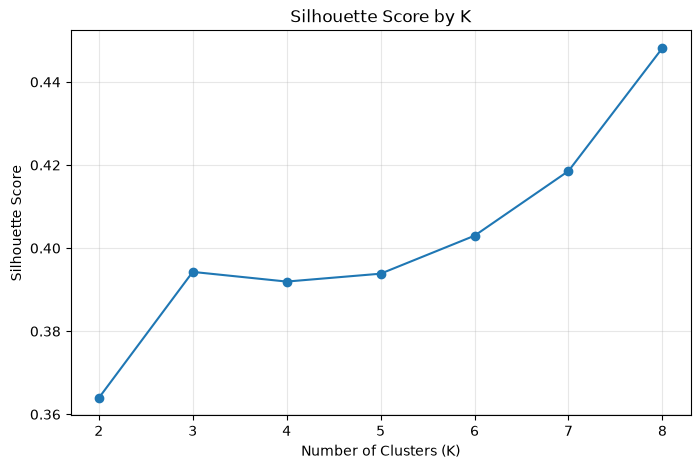

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    k_results_df["K"],
    k_results_df["Silhouette"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by K")
plt.xticks(k_results_df["K"])
plt.grid(alpha=0.3)

plt.show()

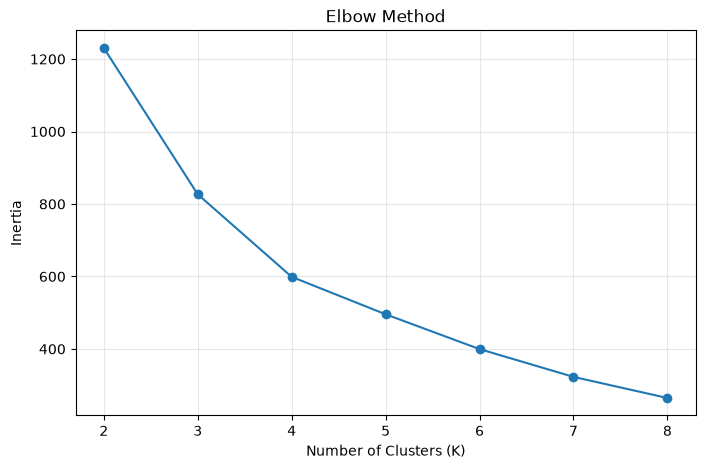

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_results_df["K"],
    k_results_df["Inertia"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(k_results_df["K"])
plt.grid(alpha=0.3)

plt.show()

In [39]:
best_k = int(
    k_results_df.loc[
        k_results_df["Silhouette"].idxmax(),
        "K"
    ]
)

best_silhouette = k_results_df.loc[
    k_results_df["Silhouette"].idxmax(),
    "Silhouette"
]

print("최적 K:", best_k)
print(f"최고 실루엣 점수: {best_silhouette:.4f}")

최적 K: 8
최고 실루엣 점수: 0.4482


a. 최적 K(=8)로 군집화

In [40]:
final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=30
)

travel_profile["CLUSTER"] = (
    final_kmeans.fit_predict(X_model)
)

travel_profile[
    [
        "TRAVEL_ID",
        "체험_방문비율",
        "식도락_방문비율",
        "쇼핑_방문비율",
        "CLUSTER"
    ]
].head()

ACTIVITY_TYPE,TRAVEL_ID,체험_방문비율,식도락_방문비율,쇼핑_방문비율,CLUSTER
0,a_a000155,0.625000,0.250000,0.125000,7
1,a_a000193,0.300000,0.600000,0.100000,6
2,a_a000202,0.750000,0.250000,0.000000,7
3,a_a000273,0.333333,0.666667,0.000000,6
4,a_a000316,0.461538,0.461538,0.076923,1


In [41]:
cluster_size = (
    travel_profile["CLUSTER"]
    .value_counts()
    .sort_index()
    .rename("여행수")
    .reset_index()
)

cluster_size

,CLUSTER,여행수
0,0,2182
1,1,3523
2,2,879
3,3,429
4,4,1536
5,5,588
6,6,2232
7,7,1642


In [42]:
from sklearn.metrics import silhouette_samples

travel_profile["SILHOUETTE"] = silhouette_samples(
    X_model,
    travel_profile["CLUSTER"]
)

travel_profile[
    ["TRAVEL_ID", "CLUSTER", "SILHOUETTE"]
].head()

ACTIVITY_TYPE,TRAVEL_ID,CLUSTER,SILHOUETTE
0,a_a000155,7,0.442564
1,a_a000193,6,0.477097
2,a_a000202,7,0.679302
3,a_a000273,6,0.625898
4,a_a000316,1,0.578341


In [43]:
cluster_profile = (
    travel_profile
    .groupby("CLUSTER")
    .agg(
        여행수=("TRAVEL_ID", "count"),
        체험_방문비율=("체험_방문비율", "mean"),
        식도락_방문비율=("식도락_방문비율", "mean"),
        쇼핑_방문비율=("쇼핑_방문비율", "mean"),
        평균_활동방문수=("활동_방문수", "mean"),
        평균_실루엣=("SILHOUETTE", "mean")
    )
    .reset_index()
)

cluster_profile["구성비"] = (
    cluster_profile["여행수"]
    / cluster_profile["여행수"].sum()
)

cluster_profile

,CLUSTER,여행수,체험_방문비율,식도락_방문비율,쇼핑_방문비율,평균_활동방문수,평균_실루엣,구성비
0,0,2182,0.216130,0.438318,0.345552,7.196150,0.313510,0.167704
1,1,3523,0.478854,0.456279,0.064866,7.376951,0.400487,0.270771
2,2,879,0.986803,0.004880,0.008317,2.503982,0.899152,0.067558
3,3,429,0.100534,0.105369,0.794098,3.918415,0.419215,0.032972
4,4,1536,0.520988,0.156369,0.322643,6.294922,0.338303,0.118054
5,5,588,0.015900,0.942796,0.041304,3.297619,0.663156,0.045193
6,6,2232,0.293731,0.654189,0.052080,7.181900,0.450018,0.171547
7,7,1642,0.692150,0.278376,0.029474,6.448234,0.518853,0.126201


In [44]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False

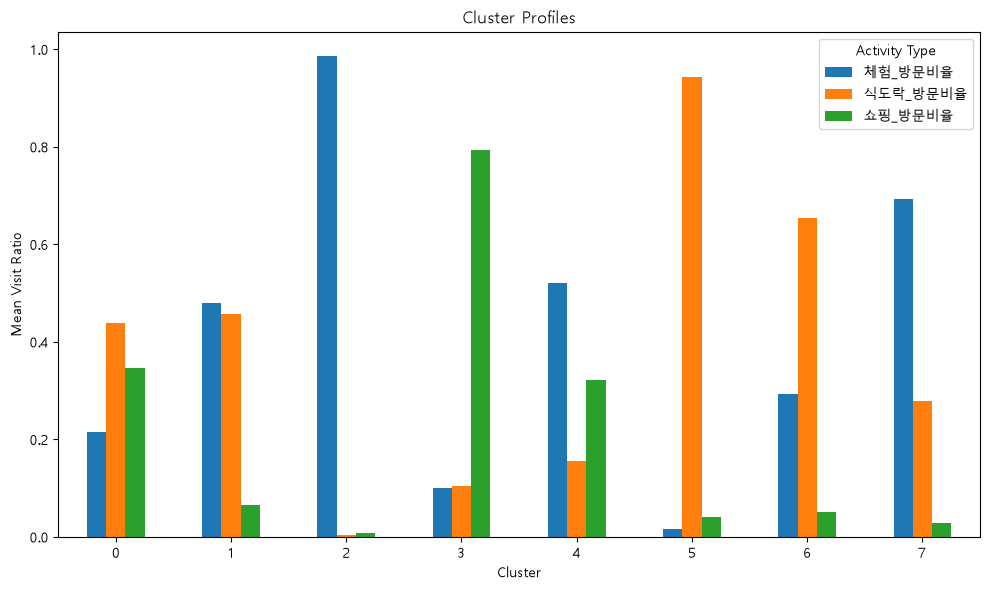

In [45]:
cluster_profile_plot = (
    cluster_profile
    .set_index("CLUSTER")[
        [
            "체험_방문비율",
            "식도락_방문비율",
            "쇼핑_방문비율"
        ]
    ]
)

cluster_profile_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Cluster")
plt.ylabel("Mean Visit Ratio")
plt.title("Cluster Profiles")
plt.xticks(rotation=0)
plt.legend(title="Activity Type")
plt.tight_layout()

plt.show()

In [46]:
# K=8 군집 이름 지정

cluster_name_map = {
    0: "미식·쇼핑형",
    1: "밸런스 탐험형",
    2: "체험 몰입형",
    3: "쇼핑 몰입형",
    4: "액티비티형",
    5: "미식 몰입형",
    6: "미식 탐방형",
    7: "체험 선호형"
}

# 군집 결과 데이터프레임에 이름 열 추가
travel_profile["CLUSTER_NAME"] = (
    travel_profile["CLUSTER"]
    .map(cluster_name_map)
)

travel_profile[
    [
        "TRAVEL_ID",
        "CLUSTER",
        "CLUSTER_NAME",
        "체험_방문비율",
        "식도락_방문비율",
        "쇼핑_방문비율"
    ]
].head()

ACTIVITY_TYPE,TRAVEL_ID,CLUSTER,CLUSTER_NAME,체험_방문비율,식도락_방문비율,쇼핑_방문비율
0,a_a000155,7,체험 선호형,0.625000,0.250000,0.125000
1,a_a000193,6,미식 탐방형,0.300000,0.600000,0.100000
2,a_a000202,7,체험 선호형,0.750000,0.250000,0.000000
3,a_a000273,6,미식 탐방형,0.333333,0.666667,0.000000
4,a_a000316,1,밸런스 탐험형,0.461538,0.461538,0.076923


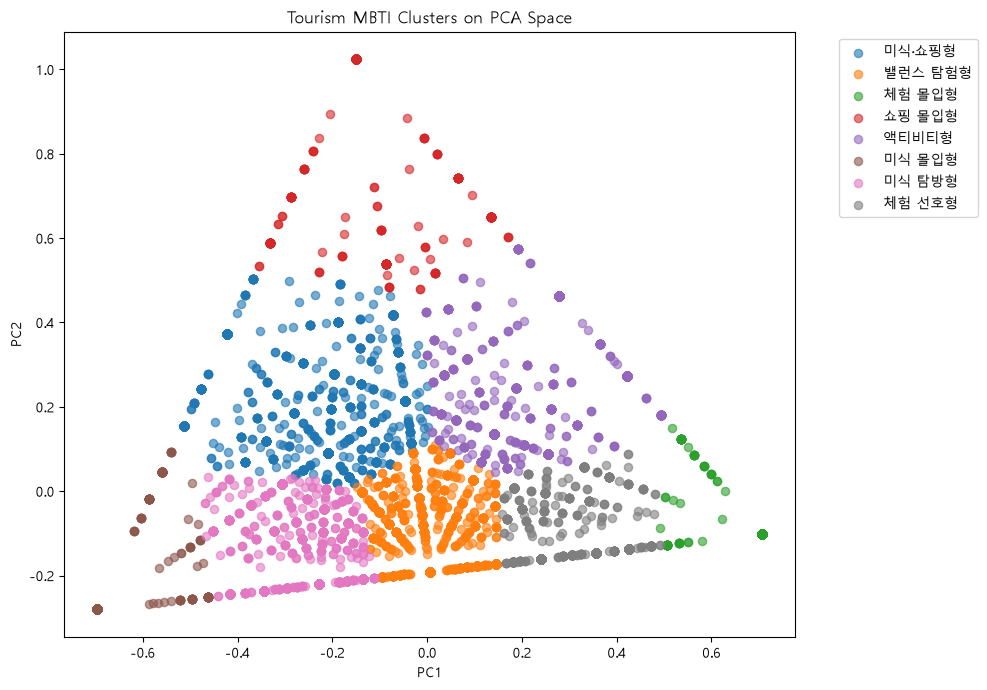

In [47]:
plt.figure(figsize=(10, 7))

for cluster in sorted(
    travel_profile["CLUSTER"].unique()
):

    subset = travel_profile[
        travel_profile["CLUSTER"] == cluster
    ]

    label = cluster_name_map.get(
        cluster,
        f"Cluster {cluster}"
    )

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=label,
        alpha=0.6,
        s=35
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Tourism MBTI Clusters on PCA Space")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()

plt.show()

b. K=6 

In [48]:
final_kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=30
)

travel_profile["CLUSTER"] = (
    final_kmeans.fit_predict(X_model)
)

travel_profile[
    [
        "TRAVEL_ID",
        "체험_방문비율",
        "식도락_방문비율",
        "쇼핑_방문비율",
        "CLUSTER"
    ]
].head()

ACTIVITY_TYPE,TRAVEL_ID,체험_방문비율,식도락_방문비율,쇼핑_방문비율,CLUSTER
0,a_a000155,0.625000,0.250000,0.125000,0
1,a_a000193,0.300000,0.600000,0.100000,1
2,a_a000202,0.750000,0.250000,0.000000,0
3,a_a000273,0.333333,0.666667,0.000000,1
4,a_a000316,0.461538,0.461538,0.076923,1


In [49]:
cluster_size = (
    travel_profile["CLUSTER"]
    .value_counts()
    .sort_index()
    .rename("여행수")
    .reset_index()
)

cluster_size

,CLUSTER,여행수
0,0,3229
1,1,3703
2,2,2806
3,3,1134
4,4,1011
5,5,1128


In [50]:
travel_profile["SILHOUETTE"] = silhouette_samples(
    X_model,
    travel_profile["CLUSTER"]
)

travel_profile[
    ["TRAVEL_ID", "CLUSTER", "SILHOUETTE"]
].head()

ACTIVITY_TYPE,TRAVEL_ID,CLUSTER,SILHOUETTE
0,a_a000155,0,0.552756
1,a_a000193,1,0.348180
2,a_a000202,0,0.236201
3,a_a000273,1,0.457404
4,a_a000316,1,0.464342


In [51]:
cluster_profile = (
    travel_profile
    .groupby("CLUSTER")
    .agg(
        여행수=("TRAVEL_ID", "count"),
        체험_방문비율=("체험_방문비율", "mean"),
        식도락_방문비율=("식도락_방문비율", "mean"),
        쇼핑_방문비율=("쇼핑_방문비율", "mean"),
        평균_활동방문수=("활동_방문수", "mean"),
        평균_실루엣=("SILHOUETTE", "mean")
    )
    .reset_index()
)

cluster_profile["구성비"] = (
    cluster_profile["여행수"]
    / cluster_profile["여행수"].sum()
)

cluster_profile


,CLUSTER,여행수,체험_방문비율,식도락_방문비율,쇼핑_방문비율,평균_활동방문수,평균_실루엣,구성비
0,0,3229,0.601846,0.278234,0.119919,7.155466,0.317426,0.248175
1,1,3703,0.424878,0.547217,0.027906,6.733729,0.490391,0.284605
2,2,2806,0.250077,0.457046,0.292877,7.710264,0.314196,0.215664
3,3,1134,0.944222,0.036995,0.018783,3.274250,0.681241,0.087157
4,4,1011,0.257140,0.124809,0.618051,4.569733,0.260303,0.077703
5,5,1128,0.107904,0.842019,0.050077,5.133865,0.430029,0.086696


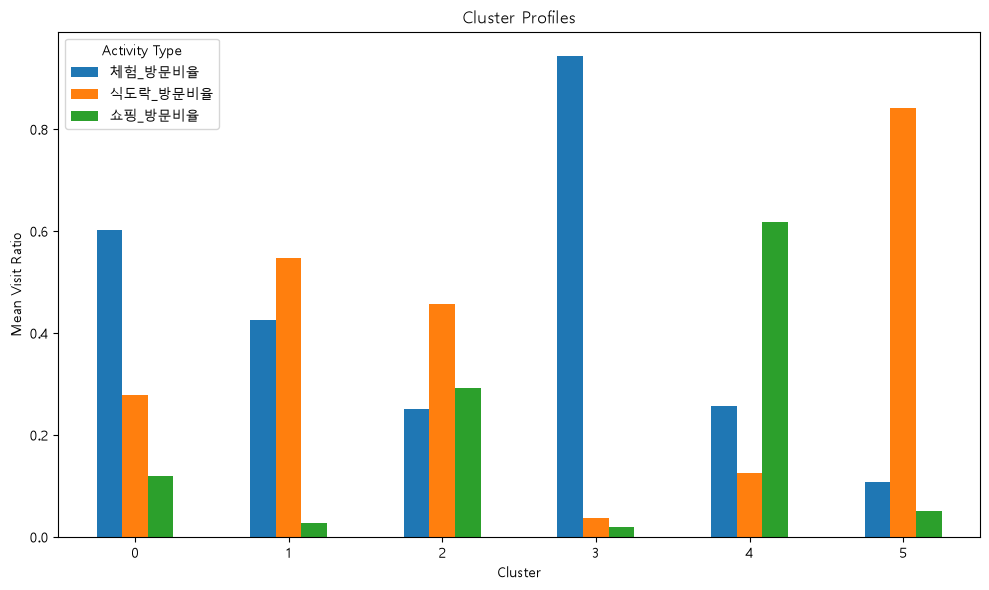

In [52]:
cluster_profile_plot = (
    cluster_profile
    .set_index("CLUSTER")[
        [
            "체험_방문비율",
            "식도락_방문비율",
            "쇼핑_방문비율"
        ]
    ]
)

cluster_profile_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Cluster")
plt.ylabel("Mean Visit Ratio")
plt.title("Cluster Profiles")
plt.xticks(rotation=0)
plt.legend(title="Activity Type")
plt.tight_layout()

plt.show()

In [53]:
# K=6 군집 이름

cluster_name_map = {
    0: "체험형",
    1: "미식 선호형",
    2: "밸런스형",
    3: "체험 몰입형",
    4: "쇼핑형",
    5: "미식 몰입형"
}

travel_profile["CLUSTER_NAME"] = (
    travel_profile["CLUSTER"]
    .map(cluster_name_map)
)

cluster_profile["CLUSTER_NAME"] = (
    cluster_profile["CLUSTER"]
    .map(cluster_name_map)
)

cluster_profile = cluster_profile[
    [
        "CLUSTER",
        "CLUSTER_NAME",
        "여행수",
        "체험_방문비율",
        "식도락_방문비율",
        "쇼핑_방문비율",
        "평균_활동방문수",
        "평균_실루엣",
        "구성비"
    ]
]

In [54]:
travel_profile["CLUSTER_NAME"] = (
    travel_profile["CLUSTER"]
    .map(cluster_name_map)
)

travel_profile[
    ["TRAVEL_ID", "CLUSTER", "CLUSTER_NAME"]
].head()

ACTIVITY_TYPE,TRAVEL_ID,CLUSTER,CLUSTER_NAME
0,a_a000155,0,체험형
1,a_a000193,1,미식 선호형
2,a_a000202,0,체험형
3,a_a000273,1,미식 선호형
4,a_a000316,1,미식 선호형


In [55]:
travel_profile[
    travel_profile["CLUSTER_NAME"].isna()
]["CLUSTER"].value_counts()

Series([], Name: count, dtype: int64)

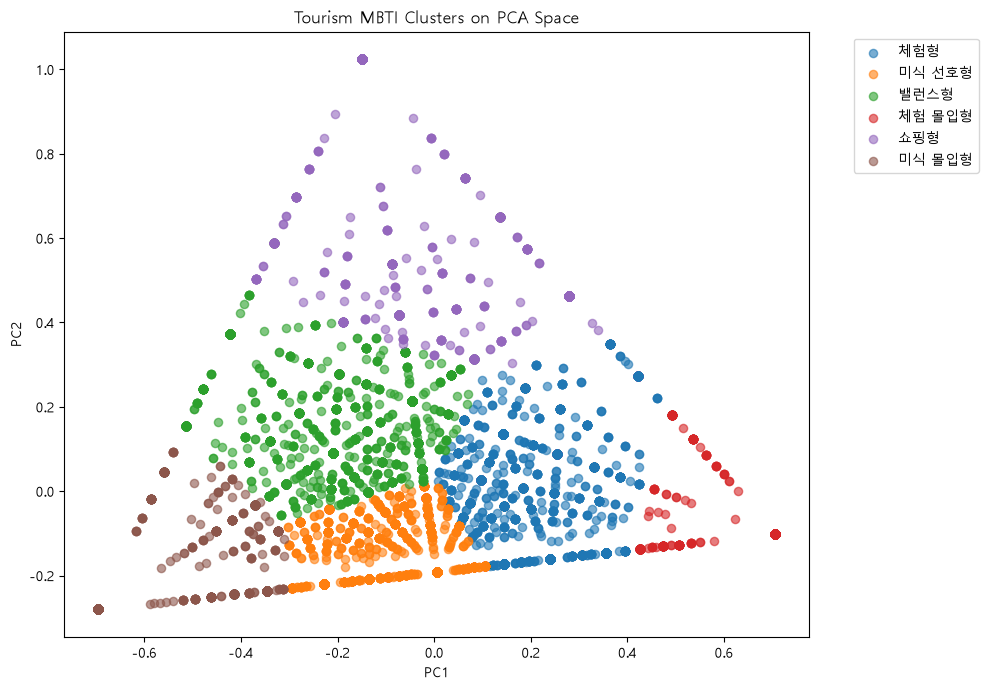

In [56]:
plt.figure(figsize=(10, 7))

for cluster in sorted(
    travel_profile["CLUSTER"].unique()
):

    subset = travel_profile[
        travel_profile["CLUSTER"] == cluster
    ]

    label = cluster_name_map.get(
        cluster,
        f"Cluster {cluster}"
    )

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=label,
        alpha=0.6,
        s=35
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Tourism MBTI Clusters on PCA Space")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()

plt.show()

K=8이 최적이었지만, 단순성과 해석 가능성을 고려해 K=6도 검토했고,
K=6은 다양한 특성을 가진 여행객이 하나의 '밸런스형' 군집으로 묶이는 반면, K=8은 이를 행동 특성에 따라 보다 명확하게 세분화되어 K=8을 최종 군집 수로 선정

# 8. 여행정보 Join

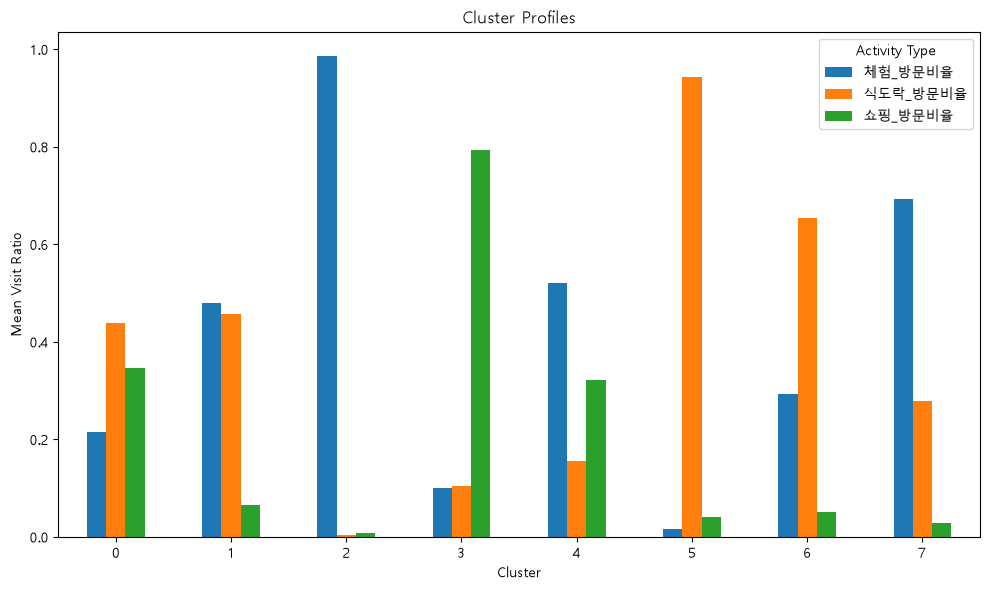

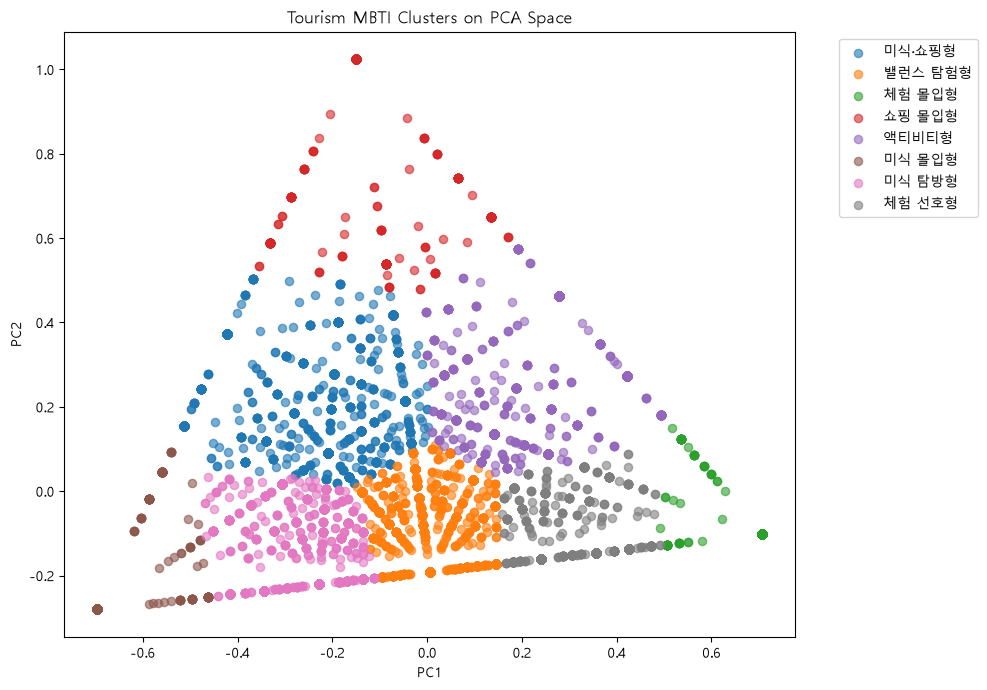

In [57]:
# 7-a의 k=8 군집화 코드와 동일

final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=30
)

travel_profile["CLUSTER"] = (
    final_kmeans.fit_predict(X_model)
)

cluster_size = (
    travel_profile["CLUSTER"]
    .value_counts()
    .sort_index()
    .rename("여행수")
    .reset_index()
)

travel_profile["SILHOUETTE"] = silhouette_samples(
    X_model,
    travel_profile["CLUSTER"]
)

cluster_profile = (
    travel_profile
    .groupby("CLUSTER")
    .agg(
        여행수=("TRAVEL_ID", "count"),
        체험_방문비율=("체험_방문비율", "mean"),
        식도락_방문비율=("식도락_방문비율", "mean"),
        쇼핑_방문비율=("쇼핑_방문비율", "mean"),
        평균_활동방문수=("활동_방문수", "mean"),
        평균_실루엣=("SILHOUETTE", "mean")
    )
    .reset_index()
)

cluster_profile["구성비"] = (
    cluster_profile["여행수"]
    / cluster_profile["여행수"].sum()
)

cluster_profile_plot = (
    cluster_profile
    .set_index("CLUSTER")[
        [
            "체험_방문비율",
            "식도락_방문비율",
            "쇼핑_방문비율"
        ]
    ]
)

cluster_profile_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Cluster")
plt.ylabel("Mean Visit Ratio")
plt.title("Cluster Profiles")
plt.xticks(rotation=0)
plt.legend(title="Activity Type")
plt.tight_layout()

# K=8 군집 이름 지정

cluster_name_map = {
    0: "미식·쇼핑형",
    1: "밸런스 탐험형",
    2: "체험 몰입형",
    3: "쇼핑 몰입형",
    4: "액티비티형",
    5: "미식 몰입형",
    6: "미식 탐방형",
    7: "체험 선호형"
}

# 군집 결과 데이터프레임에 이름 열 추가
travel_profile["CLUSTER_NAME"] = (
    travel_profile["CLUSTER"]
    .map(cluster_name_map)
)

plt.figure(figsize=(10, 7))

for cluster in sorted(
    travel_profile["CLUSTER"].unique()
):

    subset = travel_profile[
        travel_profile["CLUSTER"] == cluster
    ]

    label = cluster_name_map.get(
        cluster,
        f"Cluster {cluster}"
    )

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=label,
        alpha=0.6,
        s=35
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Tourism MBTI Clusters on PCA Space")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()

In [58]:
print(
    "travel_all의 TRAVEL_ID 중복:",
    travel_all["TRAVEL_ID"].duplicated().sum()
)

travel_all의 TRAVEL_ID 중복: 0


In [59]:
cluster_travel = travel_profile.merge(
    travel_all,
    on="TRAVEL_ID",
    how="left",
    validate="one_to_one"
)

print(cluster_travel.shape)

cluster_travel.head()

(13011, 27)


,TRAVEL_ID,REGION_x,체험_방문수,식도락_방문수,쇼핑_방문수,활동_방문수,체험_방문비율,식도락_방문비율,쇼핑_방문비율,비율합계,...,TRAVEL_PURPOSE,TRAVEL_START_YMD,TRAVEL_END_YMD,MVMN_NM,TRAVEL_PERSONA,TRAVEL_MISSION,TRAVEL_MISSION_CHECK,REGION_CODE,REGION_y,SOURCE_FILE
0,a_a000155,동부권,5,2,1,8,0.625000,0.250000,0.125000,1.0,...,2;22;5;,2022-08-26,2022-08-28,자가용,수도권 거주 39세 이하 자녀 동반,2;,2;4;22,B,동부권,tn_travel_여행_B.csv
1,a_a000193,동부권,3,6,1,10,0.300000,0.600000,0.100000,1.0,...,1;23;4;,2022-08-07,2022-08-09,대중교통 등,수도권 거주 39세 이하 커플,1;,2;23;4,B,동부권,tn_travel_여행_B.csv
2,a_a000202,서부권,3,1,0,4,0.750000,0.250000,0.000000,1.0,...,2;,2022-08-27,2022-08-29,자가용,수도권 거주 39세 이하 3인 이상 친구,2;,2;3;22,C,서부권,tn_travel_여행_C.csv
3,a_a000273,서부권,1,2,0,3,0.333333,0.666667,0.000000,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,a_a000316,동부권,6,6,1,13,0.461538,0.461538,0.076923,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
travel_join_rate = (
    cluster_travel["TRAVELER_ID"]
    .notna()
    .mean()
)

print(f"여행정보 조인율: {travel_join_rate:.2%}")

여행정보 조인율: 87.85%


In [61]:
missing_ids = set(travel_profile["TRAVEL_ID"]) - set(travel_all["TRAVEL_ID"])

print("미매칭 여행 수:", len(missing_ids))

list(missing_ids)[:20]

미매칭 여행 수: 1581


['c_c003059',
 'b_b004894',
 'b_b005127',
 'b_b010267',
 'b_b001882',
 'c_c001879',
 'c_c002270',
 'c_c005430',
 'c_c006061',
 'c_c010875',
 'b_b000815',
 'b_b003927',
 'c_c009039',
 'c_c006044',
 'c_c011819',
 'c_c005011',
 'c_c012318',
 'c_c010048',
 'c_c002412',
 'b_b006475']

In [62]:
print(
    visit_all["TRAVEL_ID"].nunique(),
    travel_profile["TRAVEL_ID"].nunique(),
    travel_all["TRAVEL_ID"].nunique()
)

13119 13011 11520


일부 여행은 원본 데이터에서 대응되는 여행정보가 존재하지 않아 제외되었으며, 이후 분석은 조인된 데이터(87.85%)를 대상으로 수행

In [63]:
print(
    "traveler_all의 TRAVELER_ID 중복:",
    traveler_all["TRAVELER_ID"].duplicated().sum()
)

traveler_all의 TRAVELER_ID 중복: 0


In [64]:
cluster_full = cluster_travel.merge(
    traveler_all,
    on="TRAVELER_ID",
    how="left",
    validate="many_to_one"
)

print(cluster_full.shape)

cluster_full.head()

(13011, 62)


,TRAVEL_ID,REGION_x,체험_방문수,식도락_방문수,쇼핑_방문수,활동_방문수,체험_방문비율,식도락_방문비율,쇼핑_방문비율,비율합계,...,TRAVEL_STYL_7,TRAVEL_STYL_8,TRAVEL_STATUS_RESIDENCE,TRAVEL_STATUS_DESTINATION,TRAVEL_STATUS_ACCOMPANY,TRAVEL_STATUS_YMD,TRAVEL_MOTIVE_1,TRAVEL_MOTIVE_2,TRAVEL_MOTIVE_3,TRAVEL_COMPANIONS_NUM
0,a_a000155,동부권,5,2,1,8,0.625000,0.250000,0.125000,1.0,...,5.0,7.0,서울특별시,경기,자녀 동반 여행,2022-08-28~2022-08-28,1.0,3.0,7.0,3.0
1,a_a000193,동부권,3,6,1,10,0.300000,0.600000,0.100000,1.0,...,6.0,2.0,서울특별시,경기,2인 여행(가족 외),2022-08-07~2022-08-08,2.0,1.0,3.0,1.0
2,a_a000202,서부권,3,1,0,4,0.750000,0.250000,0.000000,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,a_a000273,서부권,1,2,0,3,0.333333,0.666667,0.000000,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,a_a000316,동부권,6,6,1,13,0.461538,0.461538,0.076923,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
join_rate = cluster_full["TRAVELER_ID"].notna().mean()

print(f"여행객 Master 조인율: {join_rate:.2%}")

여행객 Master 조인율: 87.85%


# 9. 파생변수 생성
## 9-1. 여행일수

In [66]:
cluster_full["TRAVEL_START_YMD"] = pd.to_datetime(
    cluster_full["TRAVEL_START_YMD"],
    errors="coerce"
)

cluster_full["TRAVEL_END_YMD"] = pd.to_datetime(
    cluster_full["TRAVEL_END_YMD"],
    errors="coerce"
)

cluster_full["여행일수"] = (
    cluster_full["TRAVEL_END_YMD"]
    - cluster_full["TRAVEL_START_YMD"]
).dt.days + 1

cluster_full[
    [
        "TRAVEL_START_YMD",
        "TRAVEL_END_YMD",
        "여행일수"
    ]
].head()

,TRAVEL_START_YMD,TRAVEL_END_YMD,여행일수
0,2022-08-26,2022-08-28,3.0
1,2022-08-07,2022-08-09,3.0
2,2022-08-27,2022-08-29,3.0
3,NaT,NaT,NaN
4,NaT,NaT,NaN


## 9-2. 전체 방문지 수
활동 방문지만이 아니라, 해당 여행에서 기록된 모든 방문지 수를 계산

In [67]:
total_visit_count = (
    visit_all
    .groupby("TRAVEL_ID")
    .size()
    .rename("전체_방문지수")
    .reset_index()
)

cluster_full = cluster_full.merge(
    total_visit_count,
    on="TRAVEL_ID",
    how="left",
    validate="one_to_one"
)

cluster_full[
    ["TRAVEL_ID", "활동_방문수", "전체_방문지수"]
].head()

,TRAVEL_ID,활동_방문수,전체_방문지수
0,a_a000155,8,16
1,a_a000193,10,18
2,a_a000202,4,8
3,a_a000273,3,6
4,a_a000316,13,16


## 9-3. 전체 체류시간

In [68]:
visit_all["RESIDENCE_TIME_MIN"] = pd.to_numeric(
    visit_all["RESIDENCE_TIME_MIN"],
    errors="coerce"
)

total_stay = (
    visit_all
    .groupby("TRAVEL_ID")["RESIDENCE_TIME_MIN"]
    .sum(min_count=1)
    .rename("전체_체류시간_분")
    .reset_index()
)

cluster_full = cluster_full.merge(
    total_stay,
    on="TRAVEL_ID",
    how="left",
    validate="one_to_one"
)

cluster_full[
    ["TRAVEL_ID", "전체_체류시간_분"]
].head()

,TRAVEL_ID,전체_체류시간_분
0,a_a000155,2610.0
1,a_a000193,960.0
2,a_a000202,900.0
3,a_a000273,420.0
4,a_a000316,1080.0


## 9-4. 동행인원

In [69]:
cluster_full["TRAVEL_COMPANIONS_NUM"] = pd.to_numeric(
    cluster_full["TRAVEL_COMPANIONS_NUM"],
    errors="coerce"
)

cluster_full[
    ["TRAVEL_ID", "TRAVEL_COMPANIONS_NUM"]
].head()

,TRAVEL_ID,TRAVEL_COMPANIONS_NUM
0,a_a000155,3.0
1,a_a000193,1.0
2,a_a000202,NaN
3,a_a000273,NaN
4,a_a000316,NaN


In [70]:
# 10. 최종 군집 프로필

In [125]:
final_cluster_profile = (
    cluster_full
    .groupby(
        ["CLUSTER", "CLUSTER_NAME"],
        dropna=False
    )
    .agg(
        여행수=("TRAVEL_ID", "count"),
        체험_방문비율=("체험_방문비율", "mean"),
        식도락_방문비율=("식도락_방문비율", "mean"),
        쇼핑_방문비율=("쇼핑_방문비율", "mean"),
        평균_활동방문수=("활동_방문수", "mean"),
        평균_전체방문지수=("전체_방문지수", "mean"),
        평균_여행일수=("여행일수", "mean"),
        평균_체류시간_분=("전체_체류시간_분", "mean"),
        평균_동행인원=("TRAVEL_COMPANIONS_NUM", "mean"),
        평균_실루엣=("SILHOUETTE", "mean")
    )
    .reset_index()
)

final_cluster_profile["구성비"] = (
    final_cluster_profile["여행수"]
    / final_cluster_profile["여행수"].sum()
)

final_cluster_profile

,CLUSTER,CLUSTER_NAME,여행수,체험_방문비율,식도락_방문비율,쇼핑_방문비율,평균_활동방문수,평균_전체방문지수,평균_여행일수,평균_체류시간_분,평균_동행인원,평균_실루엣,구성비
0,0,미식·쇼핑형,2182,0.216130,0.438318,0.345552,7.196150,11.853804,2.956389,1130.540788,1.447614,0.313510,0.167704
1,1,밸런스 탐험형,3523,0.478854,0.456279,0.064866,7.376951,11.900085,3.055754,1143.380641,1.504741,0.400487,0.270771
2,2,체험 몰입형,879,0.986803,0.004880,0.008317,2.503982,5.169511,2.323097,708.498294,1.802862,0.899152,0.067558
3,3,쇼핑 몰입형,429,0.100534,0.105369,0.794098,3.918415,7.417249,2.418182,808.181818,1.315186,0.419215,0.032972
4,4,액티비티형,1536,0.520988,0.156369,0.322643,6.294922,10.389974,2.821507,1031.464844,1.476658,0.338303,0.118054
5,5,미식 몰입형,588,0.015900,0.942796,0.041304,3.297619,6.724490,2.496970,734.132653,1.421546,0.663156,0.045193
6,6,미식 탐방형,2232,0.293731,0.654189,0.052080,7.181900,11.946237,3.066191,1170.819892,1.397291,0.450018,0.171547
7,7,체험 선호형,1642,0.692150,0.278376,0.029474,6.448234,10.218636,2.786978,978.544458,1.609414,0.518853,0.126201


# 11. 카이제곱 검정

In [123]:
from scipy.stats import chi2_contingency

In [124]:
def run_chi_square(data, categorical_column):

    test_data = data[
        ["CLUSTER_NAME", categorical_column]
    ].dropna()

    contingency_table = pd.crosstab(
        test_data["CLUSTER_NAME"],
        test_data[categorical_column]
    )

    chi2, p_value, dof, expected = (
        chi2_contingency(contingency_table)
    )

    result = {
        "변수": categorical_column,
        "Chi-square": chi2,
        "자유도": dof,
        "p-value": p_value,
        "유의성": (
            "유의"
            if p_value < 0.05
            else "유의하지 않음"
        )
    }

    return result, contingency_table

In [128]:
from scipy.stats import chi2_contingency
import pandas as pd

def check_chi_square_assumption(df, group_col, category_col):
    """
    카이제곱 검정의 기대빈도 가정 확인

    Parameters
    ----------
    df : DataFrame
    group_col : 군집 변수 (예: CLUSTER_NAME)
    category_col : 범주형 변수 (예: AGE_GRP)

    Returns
    -------
    crosstab : 관측빈도표
    expected_df : 기대빈도표
    """

    # 교차표
    crosstab = pd.crosstab(df[group_col], df[category_col])

    # 카이제곱 계산
    chi2, p, dof, expected = chi2_contingency(crosstab)

    # 기대빈도 DataFrame
    expected_df = pd.DataFrame(
        expected,
        index=crosstab.index,
        columns=crosstab.columns
    )

    # 가정 확인
    low5 = (expected < 5).sum()
    low1 = (expected < 1).sum()
    total = expected.size

    print("="*60)
    print(f"[{category_col}]")
    print(f"최소 기대빈도 : {expected.min():.2f}")
    print(f"기대빈도 < 5 : {low5}/{total} ({low5/total*100:.1f}%)")
    print(f"기대빈도 < 1 : {low1}")

    if expected.min() >= 1 and low5/total <= 0.2:
        print("✅ 카이제곱 검정 가정 만족")
    else:
        print("❌ 카이제곱 검정 가정 불만족")

    return crosstab, expected_df

## 11-1. 성별 검정

In [74]:
gender_result, gender_table = run_chi_square(
    cluster_full,
    "GENDER"
)

gender_result

{'변수': 'GENDER',
 'Chi-square': np.float64(13.130767249426984),
 '자유도': 7,
 'p-value': np.float64(0.06898564869827845),
 '유의성': '유의하지 않음'}

In [75]:
gender_table

GENDER,남,여
CLUSTER_NAME,,
미식 몰입형,170,257
미식 탐방형,639,1133
미식·쇼핑형,671,1152
밸런스 탐험형,1069,1673
쇼핑 몰입형,150,199
액티비티형,485,736
체험 몰입형,260,369
체험 선호형,469,742


## 11-2. 연령대 검정

In [76]:
age_result, age_table = run_chi_square(
    cluster_full,
    "AGE_GRP"
)

age_result

{'변수': 'AGE_GRP',
 'Chi-square': np.float64(372.75866108132163),
 '자유도': 28,
 'p-value': np.float64(6.435622180568023e-62),
 '유의성': '유의'}

In [77]:
age_table

AGE_GRP,20.0,30.0,40.0,50.0,60.0
CLUSTER_NAME,,,,,
미식 몰입형,165,176,61,16,9
미식 탐방형,742,637,246,90,57
미식·쇼핑형,781,597,265,112,68
밸런스 탐험형,949,1001,485,230,77
쇼핑 몰입형,120,134,67,12,16
액티비티형,384,417,242,119,59
체험 몰입형,132,206,170,73,48
체험 선호형,295,414,278,147,77


In [129]:
gender_table, gender_expected = check_chi_square_assumption(
    cluster_full,
    "CLUSTER_NAME",
    "GENDER"
)

[GENDER]
최소 기대빈도 : 134.23
기대빈도 < 5 : 0/16 (0.0%)
기대빈도 < 1 : 0
✅ 카이제곱 검정 가정 만족


## 11-3. 동행유형 검정

In [78]:
accompany_result, accompany_table = run_chi_square(
    cluster_full,
    "TRAVEL_STATUS_ACCOMPANY"
)

accompany_result

{'변수': 'TRAVEL_STATUS_ACCOMPANY',
 'Chi-square': np.float64(436.3256759168503),
 '자유도': 49,
 'p-value': np.float64(1.4565479142972145e-63),
 '유의성': '유의'}

In [79]:
accompany_table

TRAVEL_STATUS_ACCOMPANY,2인 가족 여행,2인 여행(가족 외),3대 동반 여행(친척 포함),3인 이상 가족 여행(친척 포함),3인 이상 여행(가족 외),나홀로 여행,부모 동반 여행,자녀 동반 여행
CLUSTER_NAME,,,,,,,,
미식 몰입형,40,152,8,0,68,105,13,41
미식 탐방형,169,698,27,0,261,377,65,175
미식·쇼핑형,198,690,43,2,248,383,72,187
밸런스 탐험형,268,835,60,1,348,645,135,450
쇼핑 몰입형,34,99,1,0,42,114,13,46
액티비티형,133,304,28,2,134,325,56,239
체험 몰입형,46,107,19,0,97,167,17,176
체험 선호형,128,265,42,1,135,339,50,251


In [130]:
companion_table, companion_expected = check_chi_square_assumption(
    cluster_full,
    "CLUSTER_NAME",
    "TRAVEL_STATUS_ACCOMPANY"
)

[TRAVEL_STATUS_ACCOMPANY]
최소 기대빈도 : 0.21
기대빈도 < 5 : 8/64 (12.5%)
기대빈도 < 1 : 5
❌ 카이제곱 검정 가정 불만족


In [144]:
cluster_full["TRAVEL_STATUS_ACCOMPANY"].value_counts()

TRAVEL_STATUS_ACCOMPANY
2인 여행(가족 외)           3150
나홀로 여행                2455
자녀 동반 여행              1565
3인 이상 여행(가족 외)        1333
2인 가족 여행              1016
부모 동반 여행               421
3대 동반 여행(친척 포함)        228
3인 이상 가족 여행(친척 포함)       6
Name: count, dtype: int64

In [145]:
cluster_full["TRAVEL_STATUS_ACCOMPANY"] = (
    cluster_full["TRAVEL_STATUS_ACCOMPANY"]
    .replace({
        "3인 이상 가족 여행(친척 포함)": "3대 동반 여행(친척 포함)"
    })
)

In [146]:
cluster_full["TRAVEL_STATUS_ACCOMPANY"].value_counts()

TRAVEL_STATUS_ACCOMPANY
2인 여행(가족 외)        3150
나홀로 여행             2455
자녀 동반 여행           1565
3인 이상 여행(가족 외)     1333
2인 가족 여행           1016
부모 동반 여행            421
3대 동반 여행(친척 포함)     234
Name: count, dtype: int64

In [147]:
check_chi_square_assumption(
    cluster_full,
    "CLUSTER_NAME",
    "TRAVEL_STATUS_ACCOMPANY"
)

[TRAVEL_STATUS_ACCOMPANY]
최소 기대빈도 : 8.03
기대빈도 < 5 : 0/56 (0.0%)
기대빈도 < 1 : 0
✅ 카이제곱 검정 가정 만족


(TRAVEL_STATUS_ACCOMPANY  2인 가족 여행  2인 여행(가족 외)  3대 동반 여행(친척 포함)  \
 CLUSTER_NAME                                                      
 미식 몰입형                         40          152                8   
 미식 탐방형                        169          698               27   
 미식·쇼핑형                        198          690               45   
 밸런스 탐험형                       268          835               61   
 쇼핑 몰입형                         34           99                1   
 액티비티형                         133          304               30   
 체험 몰입형                         46          107               19   
 체험 선호형                        128          265               43   
 
 TRAVEL_STATUS_ACCOMPANY  3인 이상 여행(가족 외)  나홀로 여행  부모 동반 여행  자녀 동반 여행  
 CLUSTER_NAME                                                         
 미식 몰입형                               68     105        13        41  
 미식 탐방형                              261     377        65       175  
 미식·쇼핑형                           

## 11-4. 권역 검정

In [80]:
cluster_full = cluster_full.drop(columns=["REGION_y"])
cluster_full = cluster_full.rename(columns={"REGION_x": "REGION"})

In [81]:
region_result, region_table = run_chi_square(
    cluster_full,
    "REGION"
)

region_result

{'변수': 'REGION',
 'Chi-square': np.float64(866.5465346369343),
 '자유도': 21,
 'p-value': np.float64(6.85989879745566e-170),
 '유의성': '유의'}

In [82]:
region_table

REGION,남부권,동부권,서부권,수도권
CLUSTER_NAME,,,,
미식 몰입형,52,231,236,69
미식 탐방형,566,650,641,375
미식·쇼핑형,516,578,435,653
밸런스 탐험형,803,1067,1104,549
쇼핑 몰입형,39,108,88,194
액티비티형,288,463,423,362
체험 몰입형,50,327,350,152
체험 선호형,245,526,671,200


In [131]:
region_table, region_expected = check_chi_square_assumption(
    cluster_full,
    "CLUSTER_NAME",
    "REGION"
)

[REGION]
최소 기대빈도 : 84.21
기대빈도 < 5 : 0/32 (0.0%)
기대빈도 < 1 : 0
✅ 카이제곱 검정 가정 만족


## 11-5. 결과 통합

In [83]:
chi_square_results = pd.DataFrame([
    gender_result,
    age_result,
    accompany_result,
    region_result
])

chi_square_results

,변수,Chi-square,자유도,p-value,유의성
0,GENDER,13.130767,7,6.898565e-02,유의하지 않음
1,AGE_GRP,372.758661,28,6.435622e-62,유의
2,TRAVEL_STATUS_ACCOMPANY,436.325676,49,1.456548e-63,유의
3,REGION,866.546535,21,6.859899e-170,유의


## 11-6. 시각화 - 히트맵

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

# 한글 폰트
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


def plot_chi_residual_heatmap(
    data,
    categorical_column,
    title=None,
    category_order=None,
    cluster_order=None,
    figsize=None
):
    """
    클러스터와 범주형 변수 간 카이제곱 검정을 수행하고,
    표준화 잔차 히트맵을 출력하는 함수
    """

    # 필요한 컬럼만 선택하고 결측치 제거
    test_data = data[
        ["CLUSTER_NAME", categorical_column]
    ].dropna().copy()

    # 범주 순서 지정
    if category_order is not None:
        test_data[categorical_column] = pd.Categorical(
            test_data[categorical_column],
            categories=category_order,
            ordered=True
        )

    if cluster_order is not None:
        test_data["CLUSTER_NAME"] = pd.Categorical(
            test_data["CLUSTER_NAME"],
            categories=cluster_order,
            ordered=True
        )

    # 교차표
    observed = pd.crosstab(
        test_data["CLUSTER_NAME"],
        test_data[categorical_column]
    )

    # 빈 범주가 생긴 경우 제거
    observed = observed.loc[
        observed.sum(axis=1) > 0,
        observed.sum(axis=0) > 0
    ]

    # 카이제곱 검정
    chi2, p_value, dof, expected = chi2_contingency(observed)

    expected_df = pd.DataFrame(
        expected,
        index=observed.index,
        columns=observed.columns
    )

    # 표준화 잔차
    residuals = (observed - expected_df) / np.sqrt(expected_df)

    # 히트맵에 표시할 문자
    # |잔차| >= 1.96이면 ** 표시
    annotation = residuals.copy().astype(object)

    for row in residuals.index:
        for col in residuals.columns:
            value = residuals.loc[row, col]

            if abs(value) >= 1.96:
                annotation.loc[row, col] = f"{value:.2f} **"
            else:
                annotation.loc[row, col] = f"{value:.2f}"

    # 그래프 크기 자동 설정
    if figsize is None:
        width = max(9, len(observed.columns) * 1.25)
        height = max(5, len(observed.index) * 0.7)
        figsize = (width, height)

    # 색상 범위를 좌우 대칭으로 설정
    max_abs = max(
        2,
        np.nanmax(np.abs(residuals.values))
    )

    plt.figure(figsize=figsize)

    sns.heatmap(
        residuals,
        annot=annotation,
        fmt="",
        cmap="RdBu_r",
        center=0,
        vmin=-max_abs,
        vmax=max_abs,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "표준화 잔차"}
    )

    if title is None:
        title = f"클러스터별 {categorical_column} 표준화 잔차"

    plt.title(
        f"{title}\n"
        f"χ²={chi2:.2f}, df={dof}, p={p_value:.4g}",
        fontsize=14,
        pad=15
    )

    plt.xlabel(categorical_column)
    plt.ylabel("관광 MBTI 군집")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print(f"[{categorical_column}] 카이제곱 검정")
    print(f"χ² = {chi2:.3f}")
    print(f"자유도 = {dof}")
    print(f"p-value = {p_value:.6g}")
    print("** : |표준화 잔차| ≥ 1.96")

    return {
        "chi2": chi2,
        "p_value": p_value,
        "dof": dof,
        "observed": observed,
        "expected": expected_df,
        "residuals": residuals
    }

In [85]:
cluster_order = [
    "미식·쇼핑형",
    "밸런스 탐험형",
    "체험 몰입형",
    "쇼핑 몰입형",
    "액티비티형",
    "미식 몰입형",
    "미식 탐방형",
    "체험 선호형"
]

In [86]:
[col for col in cluster_full.columns
 if "AGE" in col.upper() or "연령" in col]

['AGE_GRP']

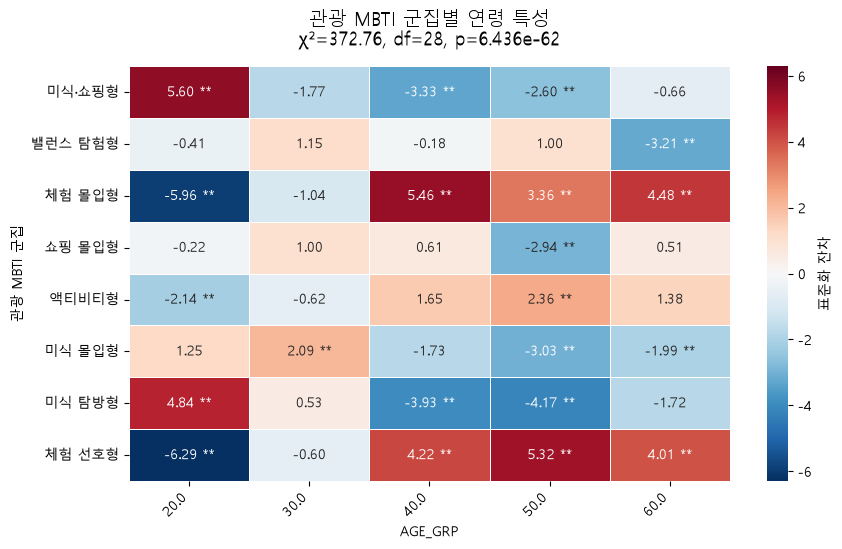

[AGE_GRP] 카이제곱 검정
χ² = 372.759
자유도 = 28
p-value = 6.43562e-62
** : |표준화 잔차| ≥ 1.96


In [87]:
age_order = [20.0, 30.0, 40.0, 50.0, 60.0]

age_result = plot_chi_residual_heatmap(
    data=cluster_full,
    categorical_column="AGE_GRP",
    title="관광 MBTI 군집별 연령 특성",
    category_order=age_order,
    cluster_order=cluster_order
)

In [88]:
[col for col in cluster_full.columns
 if "COMPAN" in col.upper() or "동행" in col]

['TRAVEL_STATUS_ACCOMPANY', 'TRAVEL_COMPANIONS_NUM']

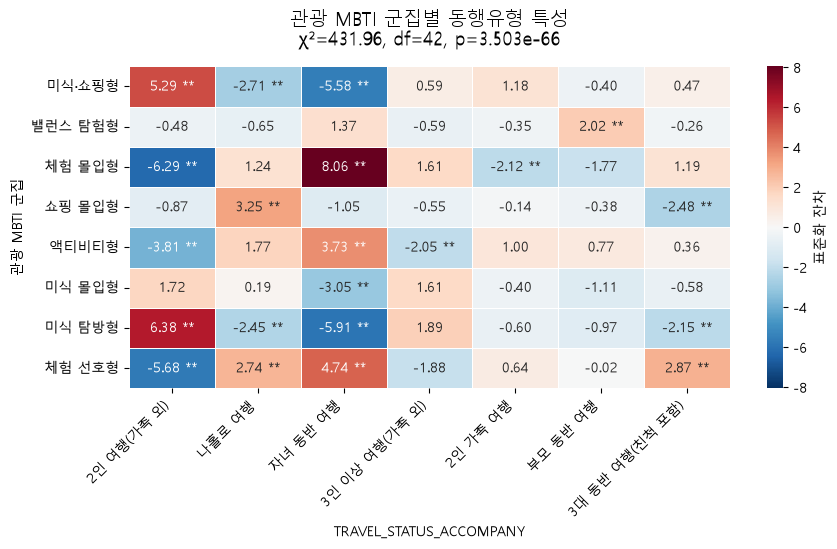

[TRAVEL_STATUS_ACCOMPANY] 카이제곱 검정
χ² = 431.964
자유도 = 42
p-value = 3.50292e-66
** : |표준화 잔차| ≥ 1.96


In [148]:
companion_order = [
    "2인 여행(가족 외)",          
    "나홀로 여행",         
    "자녀 동반 여행",         
    "3인 이상 여행(가족 외)",    
    "2인 가족 여행",          
    "부모 동반 여행",            
    "3대 동반 여행(친척 포함)"
]

companion_result = plot_chi_residual_heatmap(
    data=cluster_full,
    categorical_column="TRAVEL_STATUS_ACCOMPANY",
    title="관광 MBTI 군집별 동행유형 특성",
    category_order=companion_order,
    cluster_order=cluster_order
)

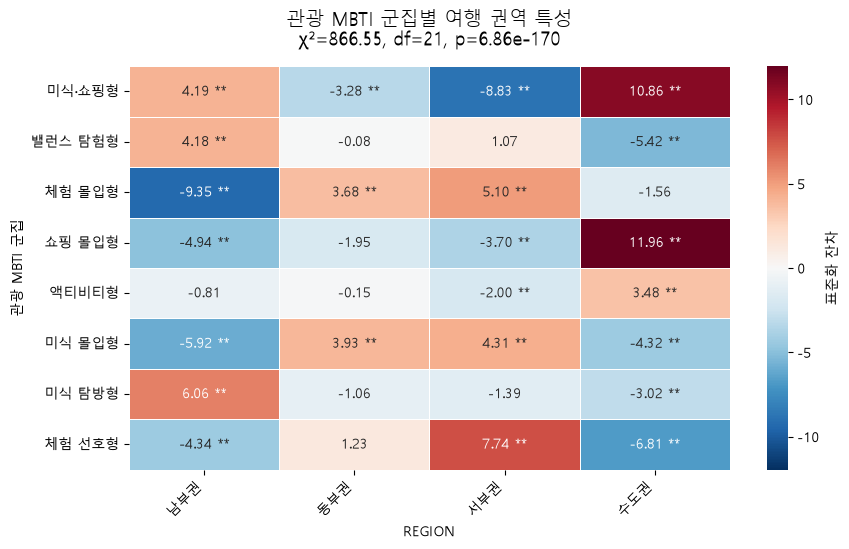

[REGION] 카이제곱 검정
χ² = 866.547
자유도 = 21
p-value = 6.8599e-170
** : |표준화 잔차| ≥ 1.96


In [90]:
region_result = plot_chi_residual_heatmap(
    data=cluster_full,
    categorical_column="REGION",
    title="관광 MBTI 군집별 여행 권역 특성",
    cluster_order=cluster_order
)

## 11-7. 시각화 - 누적 막대그래프

In [91]:
def plot_cluster_proportion(
    data,
    categorical_column,
    title=None,
    category_order=None,
    cluster_order=None,
    figsize=(12, 7)
):
    plot_data = data[
        ["CLUSTER_NAME", categorical_column]
    ].dropna().copy()

    proportion = pd.crosstab(
        plot_data["CLUSTER_NAME"],
        plot_data[categorical_column],
        normalize="index"
    ) * 100

    if cluster_order is not None:
        existing_clusters = [
            x for x in cluster_order
            if x in proportion.index
        ]
        proportion = proportion.reindex(existing_clusters)

    if category_order is not None:
        existing_categories = [
            x for x in category_order
            if x in proportion.columns
        ]
        proportion = proportion.reindex(
            columns=existing_categories
        )

    ax = proportion.plot(
        kind="barh",
        stacked=True,
        figsize=figsize,
        width=0.75
    )

    if title is None:
        title = f"군집별 {categorical_column} 구성비"

    plt.title(title, fontsize=14, pad=15)
    plt.xlabel("구성비 (%)")
    plt.ylabel("관광 MBTI 군집")
    plt.xlim(0, 100)

    plt.legend(
        title=categorical_column,
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

    return proportion

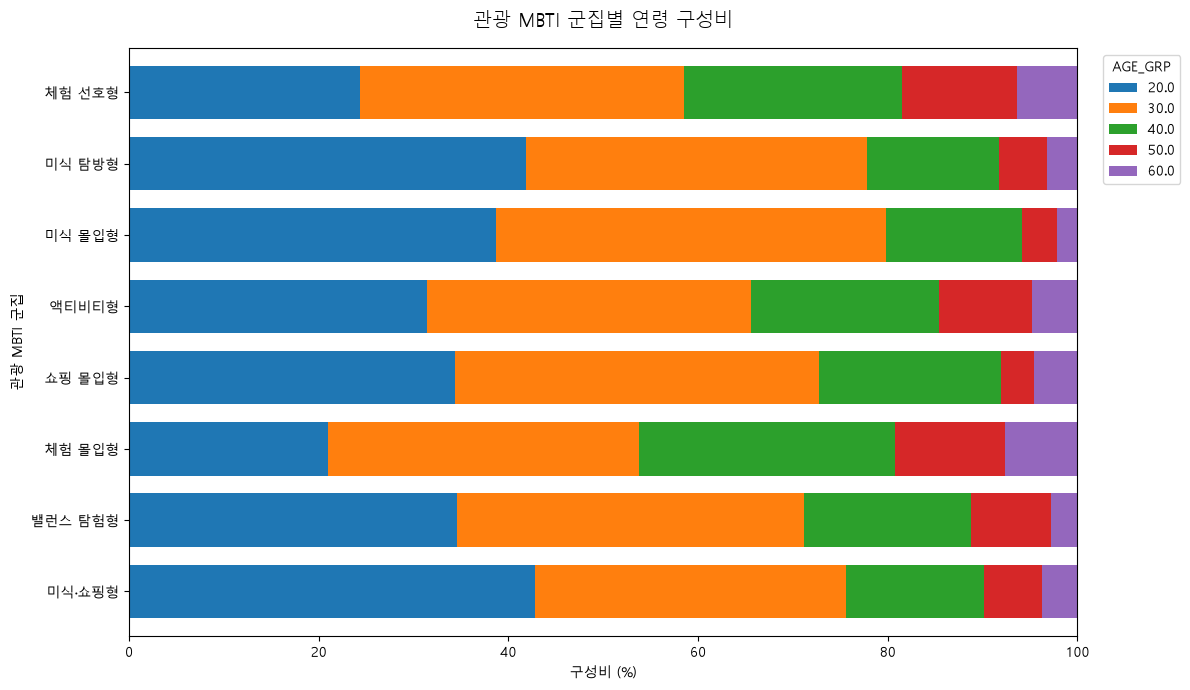

AGE_GRP,20.0,30.0,40.0,50.0,60.0
CLUSTER_NAME,,,,,
미식·쇼핑형,42.841470,32.748217,14.536478,6.143719,3.730115
밸런스 탐험형,34.609774,36.506200,17.687819,8.388038,2.808169
체험 몰입형,20.985692,32.750397,27.027027,11.605723,7.631161
쇼핑 몰입형,34.383954,38.395415,19.197708,3.438395,4.584527
액티비티형,31.449631,34.152334,19.819820,9.746110,4.832105
미식 몰입형,38.641686,41.217799,14.285714,3.747073,2.107728
미식 탐방형,41.873589,35.948081,13.882619,5.079007,3.216704
체험 선호형,24.360033,34.186623,22.956235,12.138728,6.358382


In [92]:
plot_cluster_proportion(
    cluster_full,
    "AGE_GRP",
    title="관광 MBTI 군집별 연령 구성비",
    category_order=age_order,
    cluster_order=cluster_order
)

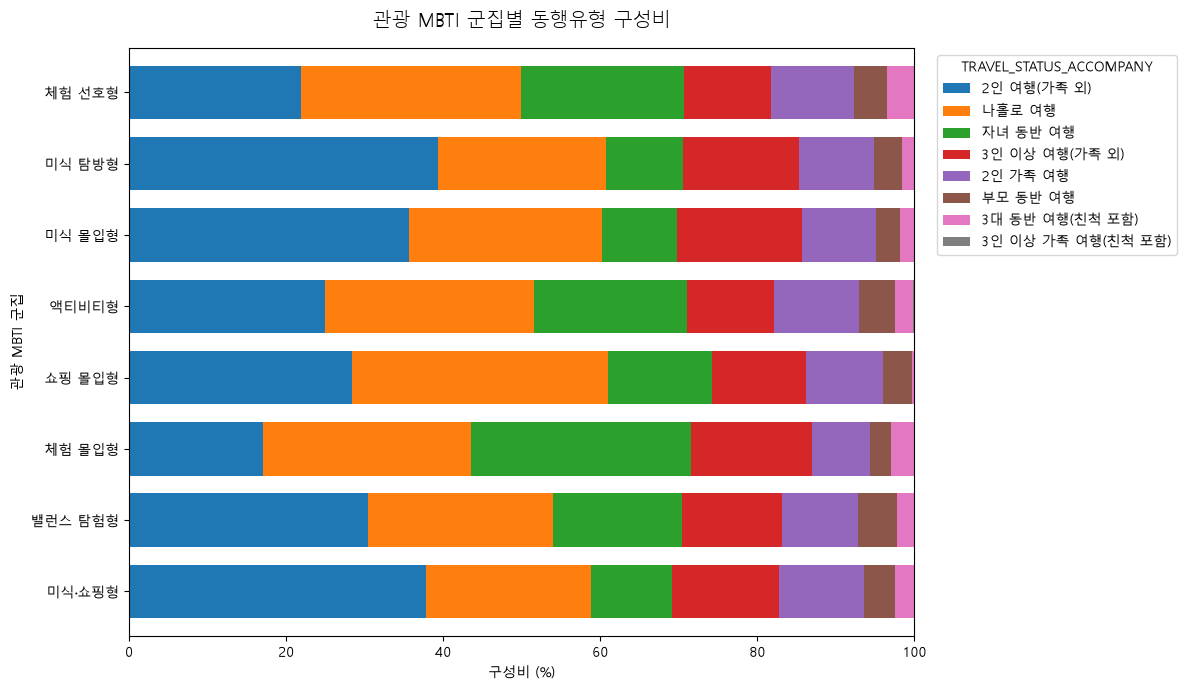

TRAVEL_STATUS_ACCOMPANY,2인 여행(가족 외),나홀로 여행,자녀 동반 여행,3인 이상 여행(가족 외),2인 가족 여행,부모 동반 여행,3대 동반 여행(친척 포함),3인 이상 가족 여행(친척 포함)
CLUSTER_NAME,,,,,,,,
미식·쇼핑형,37.849698,21.009325,10.257817,13.603950,10.861218,3.949534,2.358749,0.109709
밸런스 탐험형,30.452225,23.522976,16.411379,12.691466,9.773888,4.923414,2.188184,0.036470
체험 몰입형,17.011129,26.550079,27.980922,15.421304,7.313196,2.702703,3.020668,0.000000
쇼핑 몰입형,28.366762,32.664756,13.180516,12.034384,9.742120,3.724928,0.286533,0.000000
액티비티형,24.897625,26.617527,19.574120,10.974611,10.892711,4.586405,2.293202,0.163800
미식 몰입형,35.597190,24.590164,9.601874,15.925059,9.367681,3.044496,1.873536,0.000000
미식 탐방형,39.390519,21.275395,9.875847,14.729120,9.537246,3.668172,1.523702,0.000000
체험 선호형,21.882742,27.993394,20.726672,11.147812,10.569777,4.128819,3.468208,0.082576


In [93]:
plot_cluster_proportion(
    cluster_full,
    "TRAVEL_STATUS_ACCOMPANY",
    title="관광 MBTI 군집별 동행유형 구성비",
    category_order=companion_order,
    cluster_order=cluster_order
)

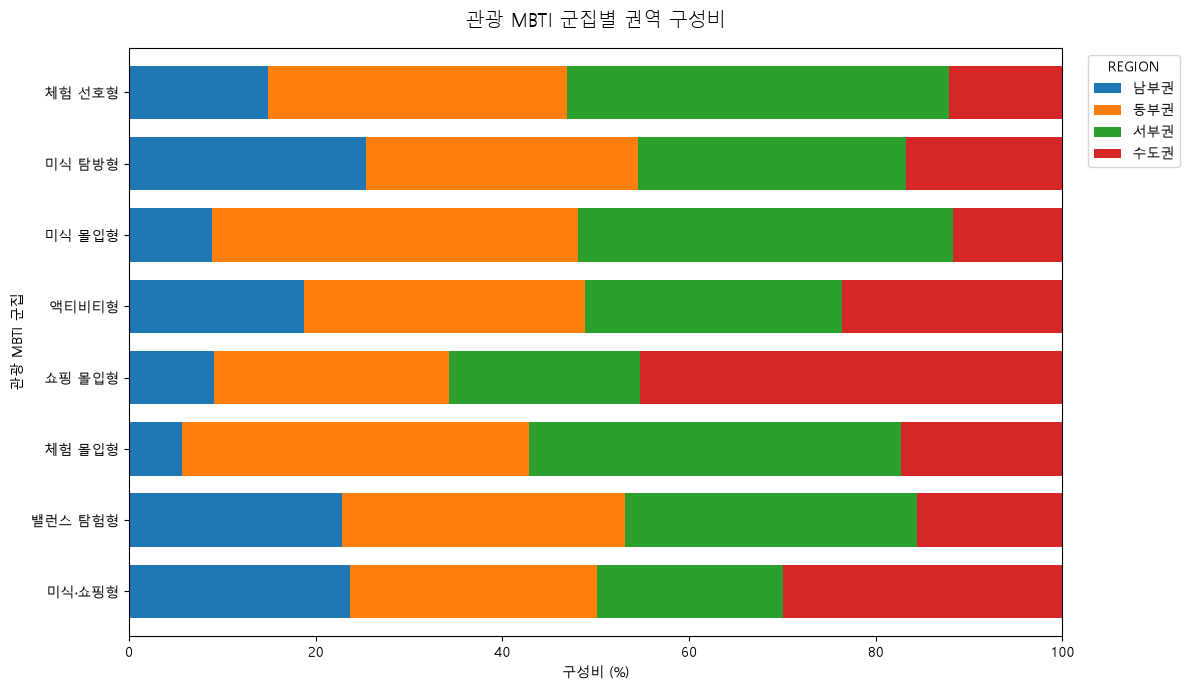

REGION,남부권,동부권,서부권,수도권
CLUSTER_NAME,,,,
미식·쇼핑형,23.648029,26.489459,19.935839,29.926673
밸런스 탐험형,22.793074,30.286687,31.336929,15.583310
체험 몰입형,5.688282,37.201365,39.817975,17.292378
쇼핑 몰입형,9.090909,25.174825,20.512821,45.221445
액티비티형,18.750000,30.143229,27.539062,23.567708
미식 몰입형,8.843537,39.285714,40.136054,11.734694
미식 탐방형,25.358423,29.121864,28.718638,16.801075
체험 선호형,14.920828,32.034105,40.864799,12.180268


In [94]:
plot_cluster_proportion(
    cluster_full,
    "REGION",
    title="관광 MBTI 군집별 권역 구성비",
    cluster_order=cluster_order
)

# 12. ANOVA

In [95]:
from scipy.stats import f_oneway

In [133]:
from scipy.stats import levene

variables = [
     "여행일수",
     "전체_방문지수",
     "전체_체류시간_분",
     "TRAVEL_COMPANIONS_NUM"
]

for var in variables:
    groups = [
        group[var].dropna()
        for _, group in cluster_full.groupby("CLUSTER_NAME")
    ]

    stat, p = levene(*groups)

    print(f"{var}")
    print(f"Levene Statistic = {stat:.3f}")
    print(f"p-value = {p:.4f}")

    if p > 0.05:
        print("✅ 등분산성 만족\n")
    else:
        print("❌ 등분산성 불만족\n")

여행일수
Levene Statistic = 53.522
p-value = 0.0000
❌ 등분산성 불만족

전체_방문지수
Levene Statistic = 72.570
p-value = 0.0000
❌ 등분산성 불만족

전체_체류시간_분
Levene Statistic = 37.350
p-value = 0.0000
❌ 등분산성 불만족

TRAVEL_COMPANIONS_NUM
Levene Statistic = 15.781
p-value = 0.0000
❌ 등분산성 불만족



In [134]:
import numpy as np
from statsmodels.stats.oneway import anova_oneway

def run_welch_anova(data, numeric_column, group_column="CLUSTER_NAME"):

    groups = []

    for cluster_name in (
        data[group_column]
        .dropna()
        .unique()
    ):

        values = (
            data.loc[
                data[group_column] == cluster_name,
                numeric_column
            ]
            .dropna()
            .astype(float)
        )

        if len(values) >= 2:
            groups.append(values.to_numpy())

    if len(groups) < 2:
        return {
            "변수": numeric_column,
            "검정": "Welch ANOVA",
            "F-statistic": np.nan,
            "자유도1": np.nan,
            "자유도2": np.nan,
            "p-value": np.nan,
            "유의성": "검정 불가"
        }

    result = anova_oneway(
        groups,
        use_var="unequal",   # 등분산을 가정하지 않음
        welch_correction=True
    )

    return {
        "변수": numeric_column,
        "검정": "Welch ANOVA",
        "F-statistic": result.statistic,
        "자유도1": result.df_num,
        "자유도2": result.df_denom,
        "p-value": result.pvalue,
        "유의성": (
            "유의"
            if result.pvalue < 0.05
            else "유의하지 않음"
        )
    }

In [135]:
numeric_columns = [
    "여행일수",
    "전체_방문지수",
    "전체_체류시간_분",
    "TRAVEL_COMPANIONS_NUM"
]

welch_results = pd.DataFrame([
    run_welch_anova(cluster_full, col)
    for col in numeric_columns
])

welch_results

,변수,검정,F-statistic,자유도1,자유도2,p-value,유의성
0,여행일수,Welch ANOVA,132.792851,7.0,2989.824665,1.252527e-170,유의
1,전체_방문지수,Welch ANOVA,361.998537,7.0,3473.833878,0.000000e+00,유의
2,전체_체류시간_분,Welch ANOVA,104.299069,7.0,3390.198853,1.249875e-138,유의
3,TRAVEL_COMPANIONS_NUM,Welch ANOVA,4.880782,7.0,2451.608318,1.749276e-05,유의


# (수정)13. Games-Howell 사후검정

In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg


def p_to_star(p):
    """p-value를 유의성 기호로 변환"""
    if pd.isna(p):
        return ""
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "-"


def run_games_howell_heatmap(
    data,
    numeric_column,
    group_column="CLUSTER_NAME",
    cluster_order=None,
    title=None,
    figsize=(10, 8),
    round_digits=2
):
    """
    Games-Howell 사후검정 수행 및 평균 차이 히트맵 생성

    Parameters
    ----------
    data : pandas.DataFrame
    numeric_column : 분석할 수치형 변수
    group_column : 군집 컬럼
    cluster_order : 히트맵에 표시할 군집 순서
    title : 히트맵 제목
    figsize : 그림 크기
    round_digits : 평균 차이 표시 소수점 자리

    Returns
    -------
    result : Games-Howell 전체 결과
    diff_matrix : 군집 간 평균 차이 행렬
    p_matrix : 군집 간 p-value 행렬
    annotation_matrix : 평균 차이와 유의성 기호가 결합된 행렬
    """

    # 필요한 컬럼만 추출하고 결측 제거
    analysis_data = (
        data[[group_column, numeric_column]]
        .dropna()
        .copy()
    )

    # 수치형 변환
    analysis_data[numeric_column] = pd.to_numeric(
        analysis_data[numeric_column],
        errors="coerce"
    )
    analysis_data = analysis_data.dropna()

    # 군집별 표본 수가 2개 이상인 군집만 사용
    valid_groups = (
        analysis_data.groupby(group_column)[numeric_column]
        .count()
    )
    valid_groups = valid_groups[valid_groups >= 2].index.tolist()

    analysis_data = analysis_data[
        analysis_data[group_column].isin(valid_groups)
    ].copy()

    if len(valid_groups) < 2:
        raise ValueError(
            f"{numeric_column}: 표본이 2개 이상인 군집이 2개 미만입니다."
        )

    # 군집 순서 설정
    if cluster_order is None:
        cluster_order = valid_groups
    else:
        cluster_order = [
            cluster
            for cluster in cluster_order
            if cluster in valid_groups
        ]

    # Games-Howell 사후검정
    result = pg.pairwise_gameshowell(
        data=analysis_data,
        dv=numeric_column,
        between=group_column
    )

    # 결과에 변수명 추가
    result.insert(0, "변수", numeric_column)

    # 평균 차이 행렬
    diff_matrix = pd.DataFrame(
        np.nan,
        index=cluster_order,
        columns=cluster_order
    )

    # p-value 행렬
    p_matrix = pd.DataFrame(
        np.nan,
        index=cluster_order,
        columns=cluster_order
    )

    # 대각선 설정
    for cluster in cluster_order:
        diff_matrix.loc[cluster, cluster] = 0.0
        p_matrix.loc[cluster, cluster] = 1.0

    # Games-Howell 결과를 행렬에 입력
    for _, row in result.iterrows():
        group_a = row["A"]
        group_b = row["B"]
        diff = row["diff"]      # mean(A) - mean(B)
        p_value = row["pval"]

        if group_a in cluster_order and group_b in cluster_order:
            # 행 군집 대비 열 군집의 평균 차이
            # # 셀 값 = 열 군집 평균 - 행 군집 평균
            diff_matrix.loc[group_a, group_b] = -diff
            diff_matrix.loc[group_b, group_a] = diff

            p_matrix.loc[group_a, group_b] = p_value
            p_matrix.loc[group_b, group_a] = p_value

    # 히트맵 표시용 문자열 행렬
    annotation_matrix = pd.DataFrame(
        "",
        index=cluster_order,
        columns=cluster_order
    )

    for row_group in cluster_order:
        for col_group in cluster_order:

            if row_group == col_group:
                annotation_matrix.loc[row_group, col_group] = ""

            elif pd.notna(diff_matrix.loc[row_group, col_group]):
                diff_value = diff_matrix.loc[row_group, col_group]
                p_value = p_matrix.loc[row_group, col_group]
                star = p_to_star(p_value)

                annotation_matrix.loc[row_group, col_group] = (
                    f"{diff_value:.{round_digits}f}\n{star}"
                )

    # 히트맵
    plt.figure(figsize=figsize)

    sns.heatmap(
        diff_matrix.astype(float),
        annot=annotation_matrix,
        fmt="",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={
            "label": f"{numeric_column} 평균 차이 (열 군집 - 행 군집)"
        }
    )

    plt.title(
        title if title else f"{numeric_column} Games-Howell 사후검정",
        fontsize=14,
        pad=15
    )
    plt.xlabel("열 군집: 비교 대상")
    plt.ylabel("행 군집: 기준 군집")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return result, diff_matrix, p_matrix, annotation_matrix

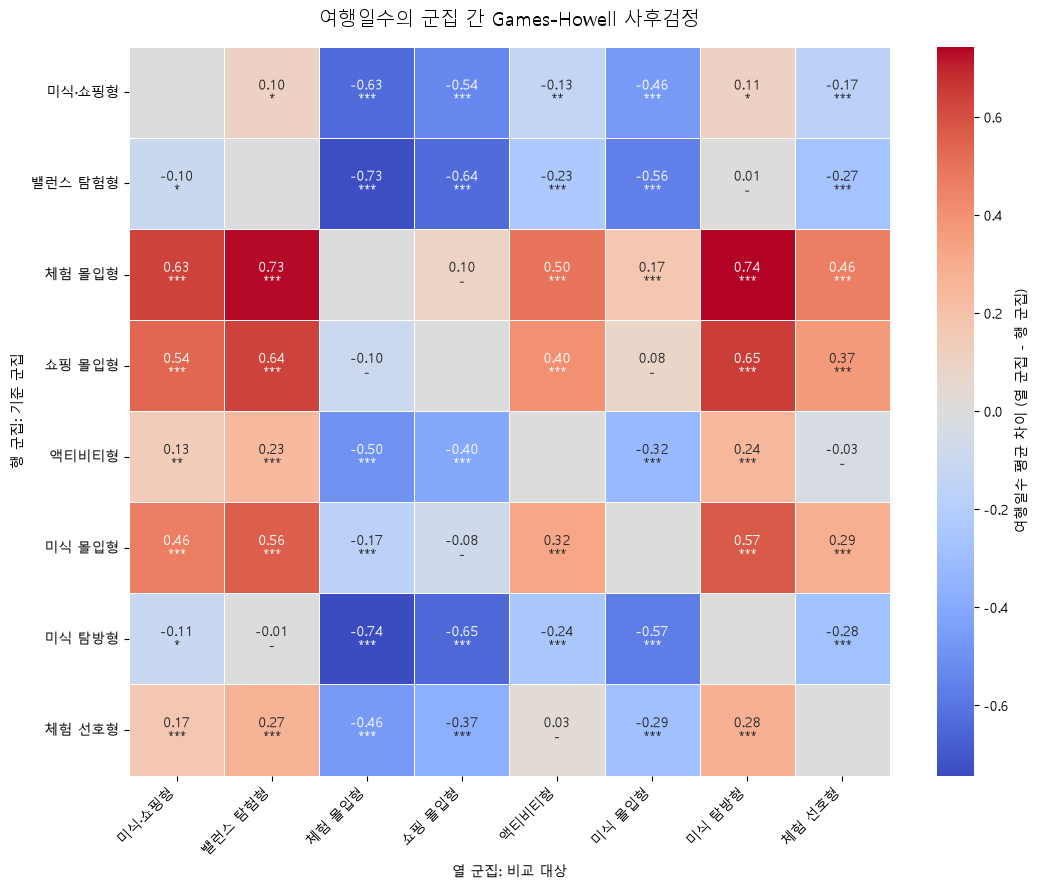

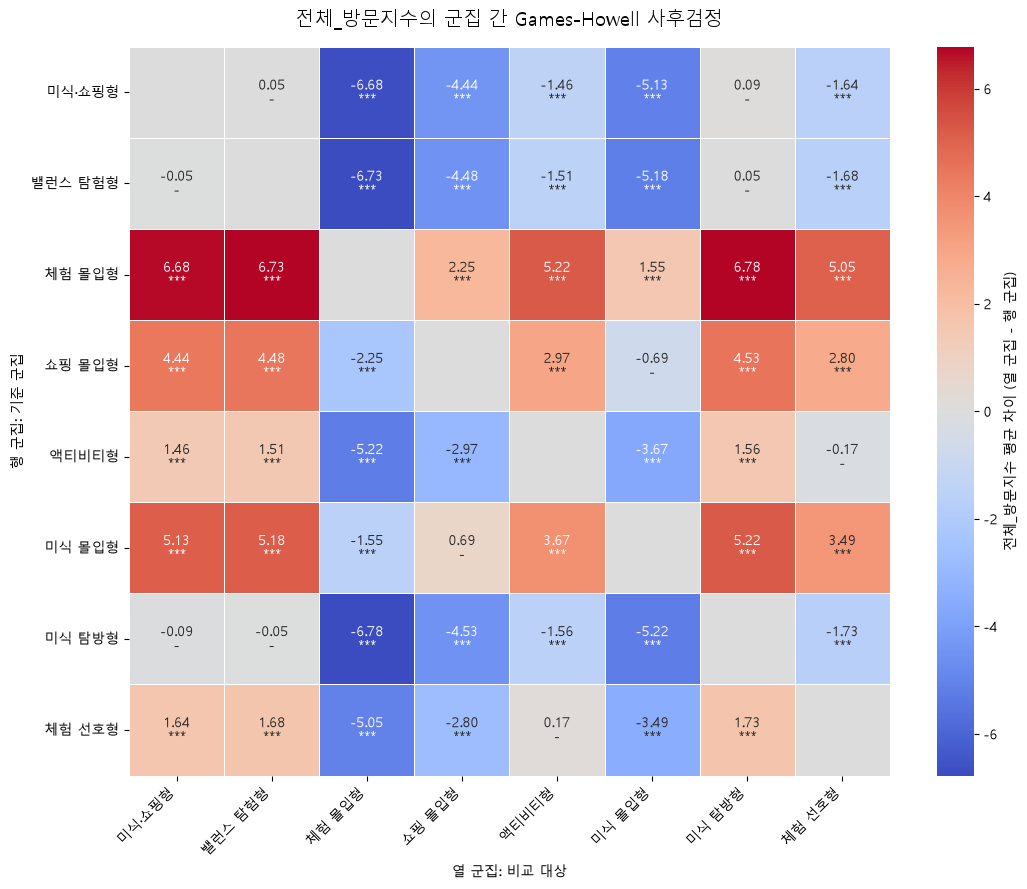

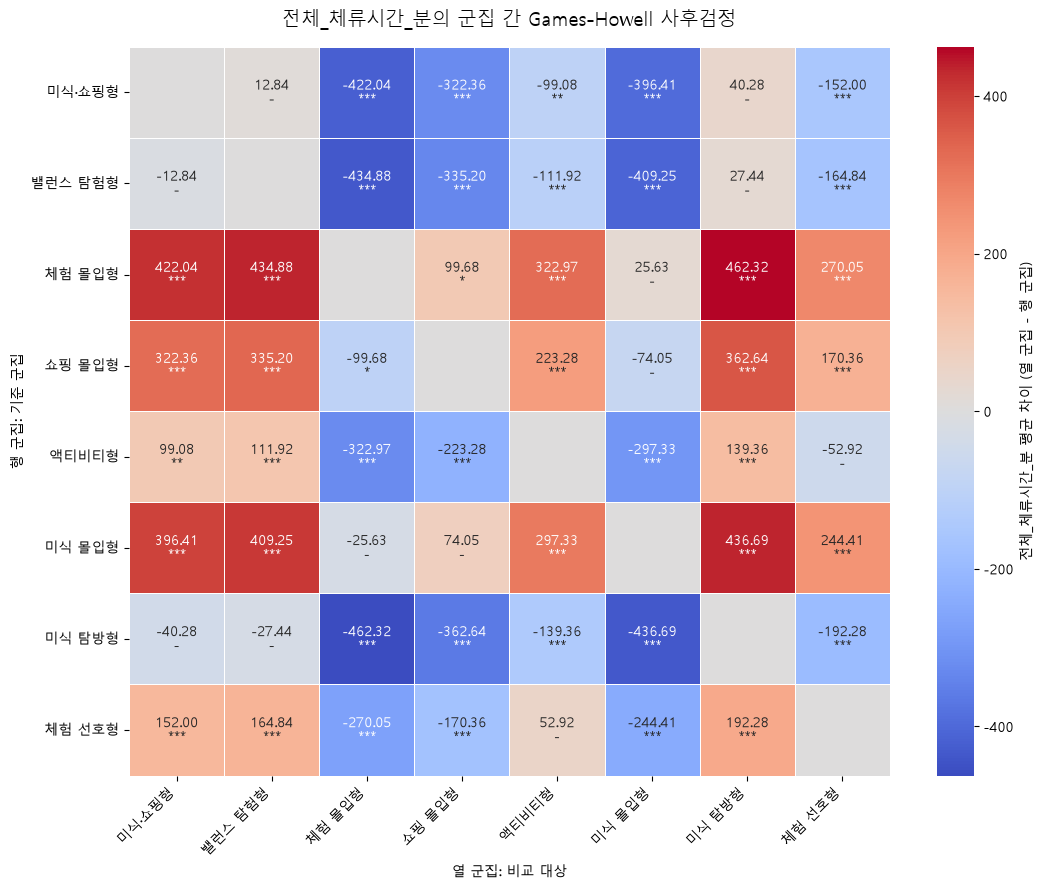

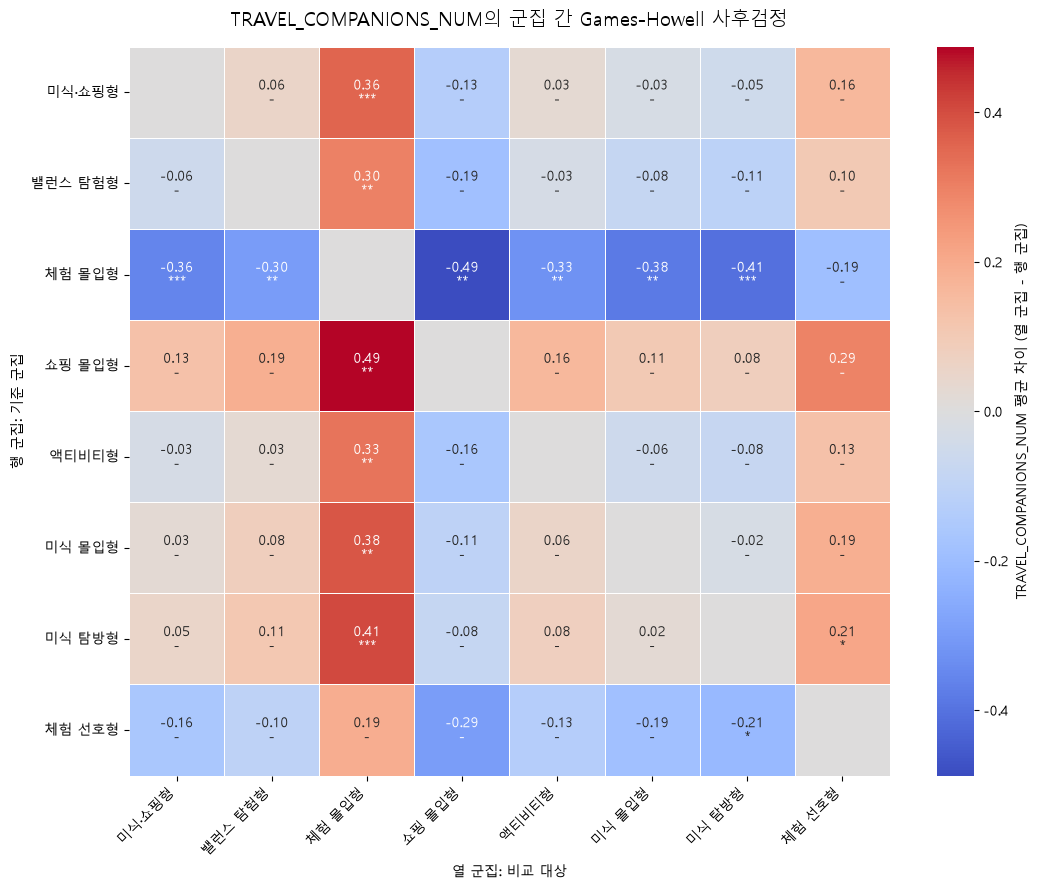

In [143]:
numeric_columns = [
    "여행일수",
    "전체_방문지수",
    "전체_체류시간_분",
    "TRAVEL_COMPANIONS_NUM"
]

games_howell_results = {}
all_games_howell_results = []

for column in numeric_columns:

    result, diff_matrix, p_matrix, annotation_matrix = (
        run_games_howell_heatmap(
            data=cluster_full,
            numeric_column=column,
            group_column="CLUSTER_NAME",
            cluster_order=cluster_order,
            title=f"{column}의 군집 간 Games-Howell 사후검정",
            figsize=(11, 9)
        )
    )

    games_howell_results[column] = {
        "result": result,
        "diff_matrix": diff_matrix,
        "p_matrix": p_matrix,
        "annotation_matrix": annotation_matrix
    }

    all_games_howell_results.append(result)

# 13. Tukey HSD 사후검정

In [98]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [99]:
def run_tukey(data, numeric_column):

    tukey_data = data[
        ["CLUSTER_NAME", numeric_column]
    ].dropna()

    result = pairwise_tukeyhsd(
        endog=tukey_data[numeric_column],
        groups=tukey_data["CLUSTER_NAME"],
        alpha=0.05
    )

    return pd.DataFrame(
        data=result.summary().data[1:],
        columns=result.summary().data[0]
    )

In [100]:
tukey_results = {}

significant_variables = (
    anova_results.loc[
        anova_results["p-value"] < 0.05,
        "변수"
    ]
    .tolist()
)

for variable in significant_variables:

    tukey_results[variable] = run_tukey(
        cluster_full,
        variable
    )

    print(f"\n[{variable}]")
    display(tukey_results[variable])


[여행일수]


,group1,group2,meandiff,p-adj,lower,upper,reject
0,미식 몰입형,미식 탐방형,0.5692,0.0000,0.4117,0.7268,True
1,미식 몰입형,미식·쇼핑형,0.4594,0.0000,0.3019,0.6169,True
2,미식 몰입형,밸런스 탐험형,0.5588,0.0000,0.4071,0.7105,True
3,미식 몰입형,쇼핑 몰입형,-0.0788,0.9522,-0.2917,0.1341,False
4,미식 몰입형,액티비티형,0.3245,0.0000,0.1602,0.4889,True
5,미식 몰입형,체험 몰입형,-0.1739,0.0717,-0.3553,0.0076,False
6,미식 몰입형,체험 선호형,0.2900,0.0000,0.1264,0.4536,True
7,미식 탐방형,미식·쇼핑형,-0.1098,0.0195,-0.2097,-0.0099,True
8,미식 탐방형,밸런스 탐험형,-0.0104,1.0000,-0.1009,0.0800,False
9,미식 탐방형,쇼핑 몰입형,-0.6480,0.0000,-0.8226,-0.4734,True



[전체_방문지수]


,group1,group2,meandiff,p-adj,lower,upper,reject
0,미식 몰입형,미식 탐방형,5.2217,0.0000,4.2425,6.2010,True
1,미식 몰입형,미식·쇼핑형,5.1293,0.0000,4.1477,6.1109,True
2,미식 몰입형,밸런스 탐험형,5.1756,0.0000,4.2345,6.1167,True
3,미식 몰입형,쇼핑 몰입형,0.6928,0.7710,-0.6486,2.0341,False
4,미식 몰입형,액티비티형,3.6655,0.0000,2.6410,4.6900,True
5,미식 몰입형,체험 몰입형,-1.5550,0.0007,-2.6805,-0.4295,True
6,미식 몰입형,체험 선호형,3.4941,0.0000,2.4789,4.5094,True
7,미식 탐방형,미식·쇼핑형,-0.0924,0.9999,-0.7284,0.5436,False
8,미식 탐방형,밸런스 탐험형,-0.0462,1.0000,-0.6177,0.5254,False
9,미식 탐방형,쇼핑 몰입형,-4.5290,0.0000,-5.6427,-3.4153,True



[전체_체류시간_분]


,group1,group2,meandiff,p-adj,lower,upper,reject
0,미식 몰입형,미식 탐방형,436.6872,0.0000,329.6086,543.7659,True
1,미식 몰입형,미식·쇼핑형,396.4081,0.0000,289.0740,503.7423,True
2,미식 몰입형,밸런스 탐험형,409.2480,0.0000,306.3415,512.1545,True
3,미식 몰입형,쇼핑 몰입형,74.0492,0.7911,-72.6263,220.7246,False
4,미식 몰입형,액티비티형,297.3322,0.0000,185.3092,409.3552,True
5,미식 몰입형,체험 몰입형,-25.6344,0.9985,-148.7026,97.4339,False
6,미식 몰입형,체험 선호형,244.4118,0.0000,133.3943,355.4293,True
7,미식 탐방형,미식·쇼핑형,-40.2791,0.6502,-109.8225,29.2643,False
8,미식 탐방형,밸런스 탐험형,-27.4393,0.8872,-89.9326,35.0540,False
9,미식 탐방형,쇼핑 몰입형,-362.6381,0.0000,-484.4139,-240.8623,True



[TRAVEL_COMPANIONS_NUM]


,group1,group2,meandiff,p-adj,lower,upper,reject
0,미식 몰입형,미식 탐방형,-0.0243,1.0000,-0.2818,0.2333,False
1,미식 몰입형,미식·쇼핑형,0.0261,1.0000,-0.2308,0.2829,False
2,미식 몰입형,밸런스 탐험형,0.0832,0.9724,-0.1654,0.3317,False
3,미식 몰입형,쇼핑 몰입형,-0.1064,0.9827,-0.4511,0.2384,False
4,미식 몰입형,액티비티형,0.0551,0.9986,-0.2135,0.3237,False
5,미식 몰입형,체험 몰입형,0.3813,0.0029,0.0817,0.6809,True
6,미식 몰입형,체험 선호형,0.1879,0.4031,-0.0810,0.4568,False
7,미식 탐방형,미식·쇼핑형,0.0503,0.9802,-0.1091,0.2097,False
8,미식 탐방형,밸런스 탐험형,0.1074,0.3296,-0.0382,0.2531,False
9,미식 탐방형,쇼핑 몰입형,-0.0821,0.9871,-0.3619,0.1977,False


In [101]:
anova_columns = [
    "여행일수",
    "전체_방문지수",
    "전체_체류시간_분",
    "TRAVEL_COMPANIONS_NUM"
]

cluster_mean_table = (
    cluster_full
    .groupby("CLUSTER_NAME")[anova_columns]
    .agg(["mean", "std", "count"])
    .round(3)
)

cluster_mean_table

여행일수              전체_방문지수              전체_체류시간_분           \
               mean    std count    mean    std count      mean      std   
CLUSTER_NAME                                                               
미식 몰입형        2.497  0.733   495   6.724  4.408   588   734.133  597.368   
미식 탐방형        3.066  1.090  1964  11.946  7.411  2232  1170.820  838.786   
미식·쇼핑형        2.956  1.057  1972  11.854  7.783  2182  1130.541  797.354   
밸런스 탐험형       3.056  1.166  3085  11.900  7.924  3523  1143.381  861.475   
쇼핑 몰입형        2.418  0.657   385   7.417  4.419   429   808.182  535.461   
액티비티형         2.822  0.912  1367  10.390  6.485  1536  1031.465  684.334   
체험 몰입형        2.323  0.646   749   5.170  3.424   879   708.498  493.997   
체험 선호형        2.787  1.061  1413  10.219  6.102  1642   978.544  660.269   

                   TRAVEL_COMPANIONS_NUM               
             count                  mean    std count  
CLUSTER_NAME                                           
미식 몰입형         588                 1.422  1.462   427  
미식 탐방형        2232                 1.397  1.421  1772  
미식·쇼핑형        2182                 1.448  1.480  1823  
밸런스 탐험형       3523                 1.505  1.542  2742  
쇼핑 몰입형         429                 1.315  1.954   349  
액티비티형         1536                 1.477  1.503  1221  
체험 몰입형         879                 1.803  1.969   629  
체험 선호형        1642                 1.609  1.758  1211

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


def plot_anova_mean_ci(
    data,
    numeric_column,
    cluster_column="CLUSTER_NAME",
    cluster_order=None,
    title=None,
    ylabel=None
):
    plot_data = data[
        [cluster_column, numeric_column]
    ].dropna().copy()

    summary = (
        plot_data
        .groupby(cluster_column)[numeric_column]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    # 표준오차와 95% 신뢰구간
    summary["se"] = summary["std"] / np.sqrt(summary["count"])
    summary["ci95"] = 1.96 * summary["se"]

    if cluster_order is not None:
        summary[cluster_column] = pd.Categorical(
            summary[cluster_column],
            categories=cluster_order,
            ordered=True
        )
        summary = summary.sort_values(cluster_column)

    plt.figure(figsize=(12, 6))

    plt.bar(
        summary[cluster_column].astype(str),
        summary["mean"],
        yerr=summary["ci95"],
        capsize=5
    )

    if title is None:
        title = f"군집별 {numeric_column} 평균 비교"

    if ylabel is None:
        ylabel = numeric_column

    plt.title(title, fontsize=14, pad=15)
    plt.xlabel("관광 MBTI 군집")
    plt.ylabel(ylabel)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

    return summary

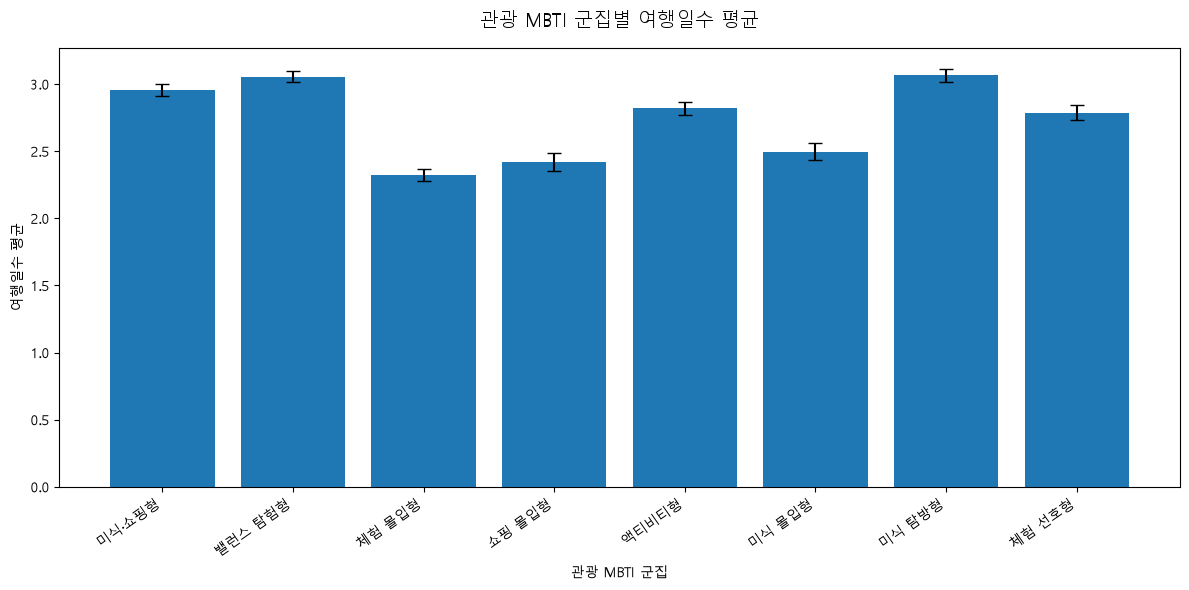

In [103]:
result_1 = plot_anova_mean_ci(
    cluster_full,
    "여행일수",
    cluster_order=cluster_order,
    title="관광 MBTI 군집별 여행일수 평균",
    ylabel="여행일수 평균"
)

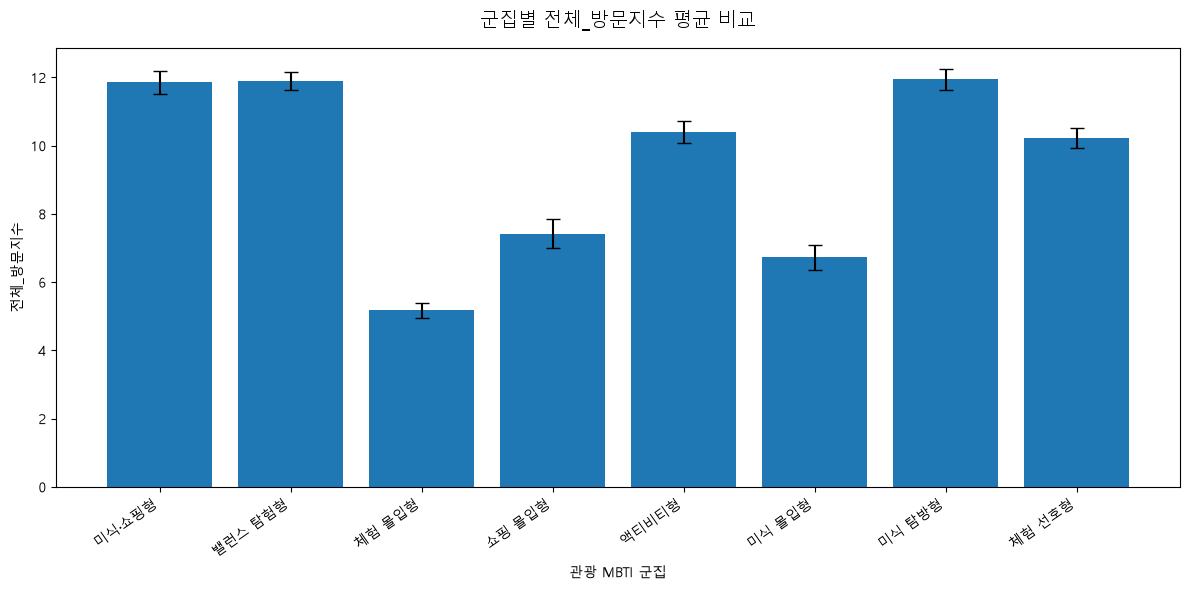

In [104]:
result_2 = plot_anova_mean_ci(
    cluster_full,
    "전체_방문지수",
    cluster_order=cluster_order
)

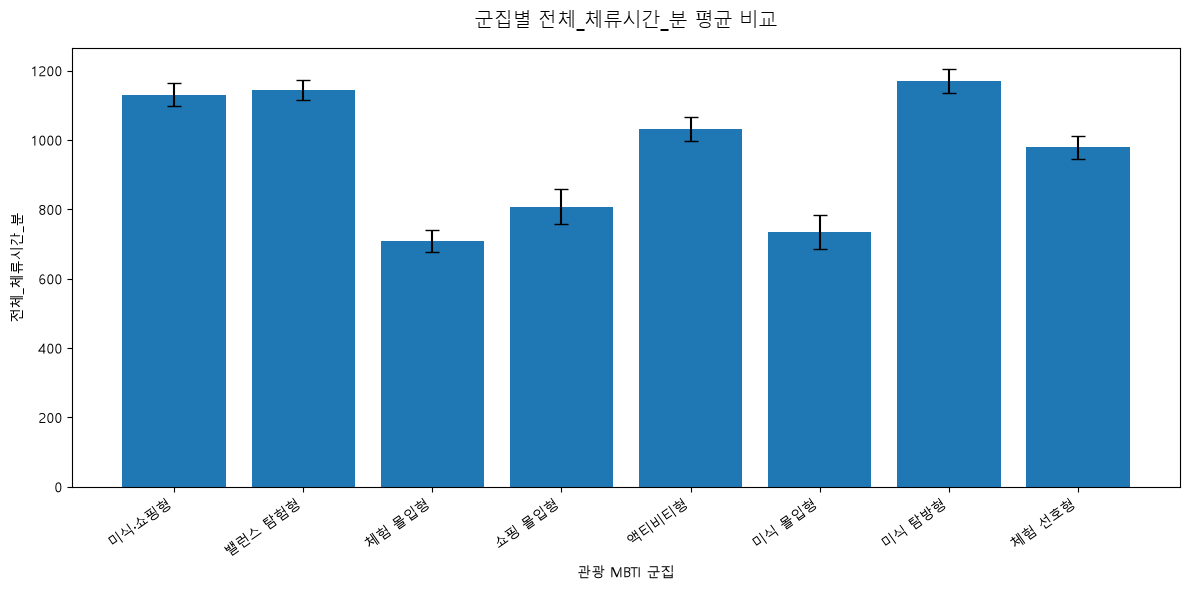

In [105]:
result_3 = plot_anova_mean_ci(
    cluster_full,
    "전체_체류시간_분",
    cluster_order=cluster_order
)

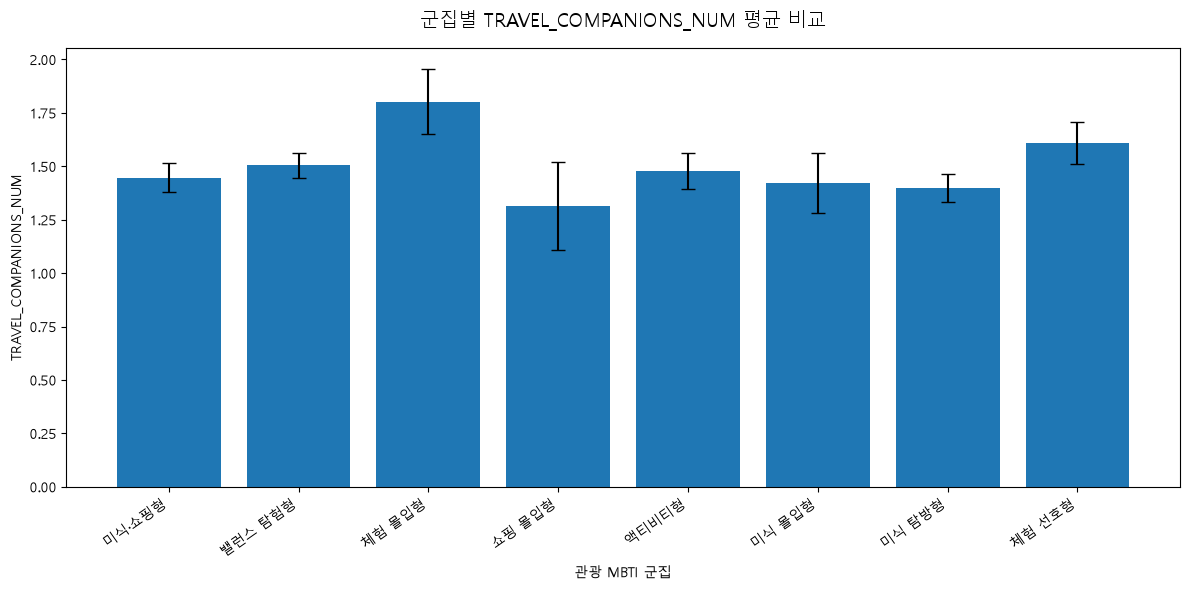

In [106]:
result_4 = plot_anova_mean_ci(
    cluster_full,
    "TRAVEL_COMPANIONS_NUM",
    cluster_order=cluster_order
)

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.stats.multicomp import pairwise_tukeyhsd


def plot_tukey_heatmap(
    data,
    numeric_column,
    cluster_column="CLUSTER_NAME",
    cluster_order=None,
    title=None
):
    test_data = data[
        [cluster_column, numeric_column]
    ].dropna().copy()

    tukey = pairwise_tukeyhsd(
        endog=test_data[numeric_column],
        groups=test_data[cluster_column],
        alpha=0.05
    )

    # Tukey 결과를 DataFrame으로 변환
    tukey_df = pd.DataFrame(
        data=tukey._results_table.data[1:],
        columns=tukey._results_table.data[0]
    )

    if cluster_order is None:
        cluster_order = sorted(
            test_data[cluster_column].unique()
        )

    matrix = pd.DataFrame(
        np.nan,
        index=cluster_order,
        columns=cluster_order
    )

    significance = pd.DataFrame(
        "",
        index=cluster_order,
        columns=cluster_order
    )

    for _, row in tukey_df.iterrows():
        group1 = row["group1"]
        group2 = row["group2"]
        mean_diff = float(row["meandiff"])
        reject = bool(row["reject"])

        # 유의한 차이만 표시
        if reject:
            matrix.loc[group1, group2] = mean_diff
            matrix.loc[group2, group1] = -mean_diff

            significance.loc[group1, group2] = f"{mean_diff:.2f}*"
            significance.loc[group2, group1] = f"{-mean_diff:.2f}*"
        else:
            matrix.loc[group1, group2] = 0
            matrix.loc[group2, group1] = 0

            significance.loc[group1, group2] = "-"
            significance.loc[group2, group1] = "-"

    for i in range(len(matrix)):
        matrix.iat[i, i] = 0

    for cluster in cluster_order:
        significance.loc[cluster, cluster] = ""

    max_abs = np.nanmax(np.abs(matrix.values))

    if max_abs == 0:
        max_abs = 1

    plt.figure(figsize=(11, 9))

    plt.imshow(
        matrix,
        cmap="RdBu_r",
        vmin=-max_abs,
        vmax=max_abs,
        aspect="auto"
    )

    plt.colorbar(label="평균 차이")

    plt.xticks(
        range(len(cluster_order)),
        cluster_order,
        rotation=45,
        ha="right"
    )
    plt.yticks(
        range(len(cluster_order)),
        cluster_order
    )

    for i in range(len(cluster_order)):
        for j in range(len(cluster_order)):
            plt.text(
                j,
                i,
                significance.iloc[i, j],
                ha="center",
                va="center"
            )

    if title is None:
        title = f"{numeric_column} Tukey 사후검정"

    plt.title(
        f"{title}\n* 유의한 군집 간 차이",
        fontsize=14,
        pad=15
    )

    plt.xlabel("비교 군집")
    plt.ylabel("기준 군집")
    plt.tight_layout()
    plt.show()

    return tukey_df

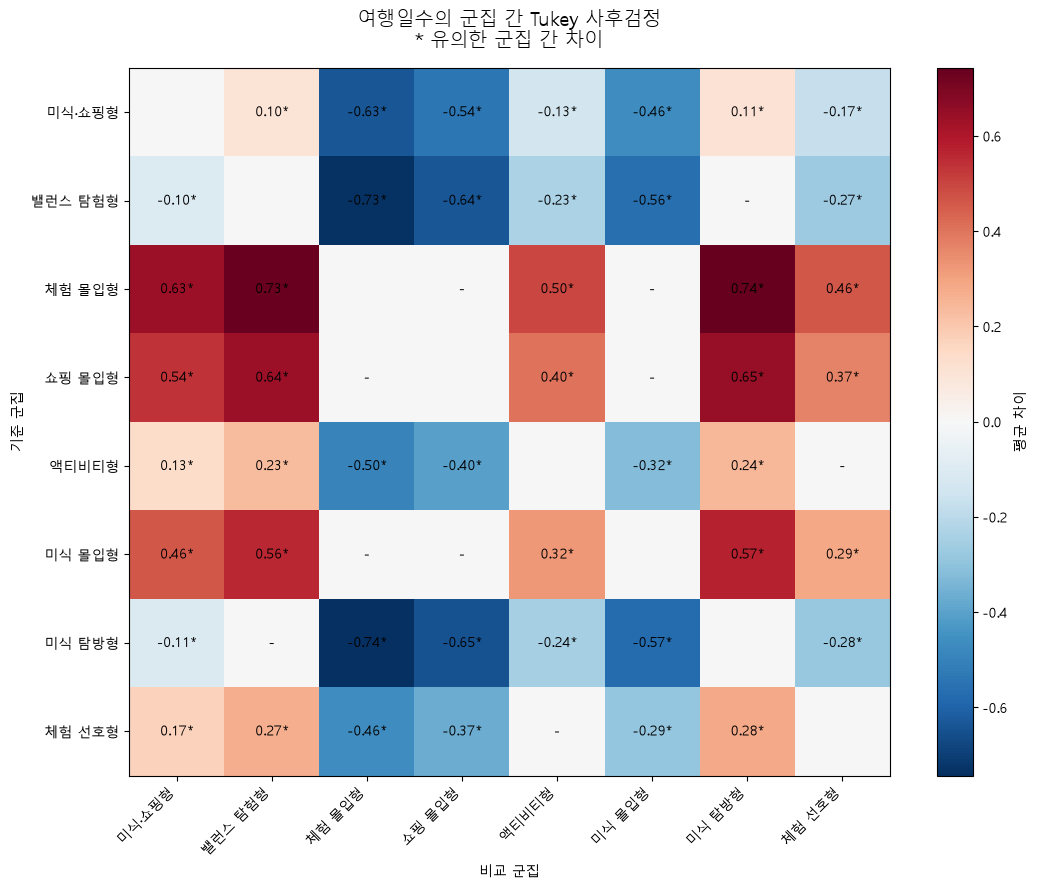

In [115]:
tukey_1 = plot_tukey_heatmap(
    cluster_full,
    "여행일수",
    cluster_order=cluster_order,
    title="여행일수의 군집 간 Tukey 사후검정"
)

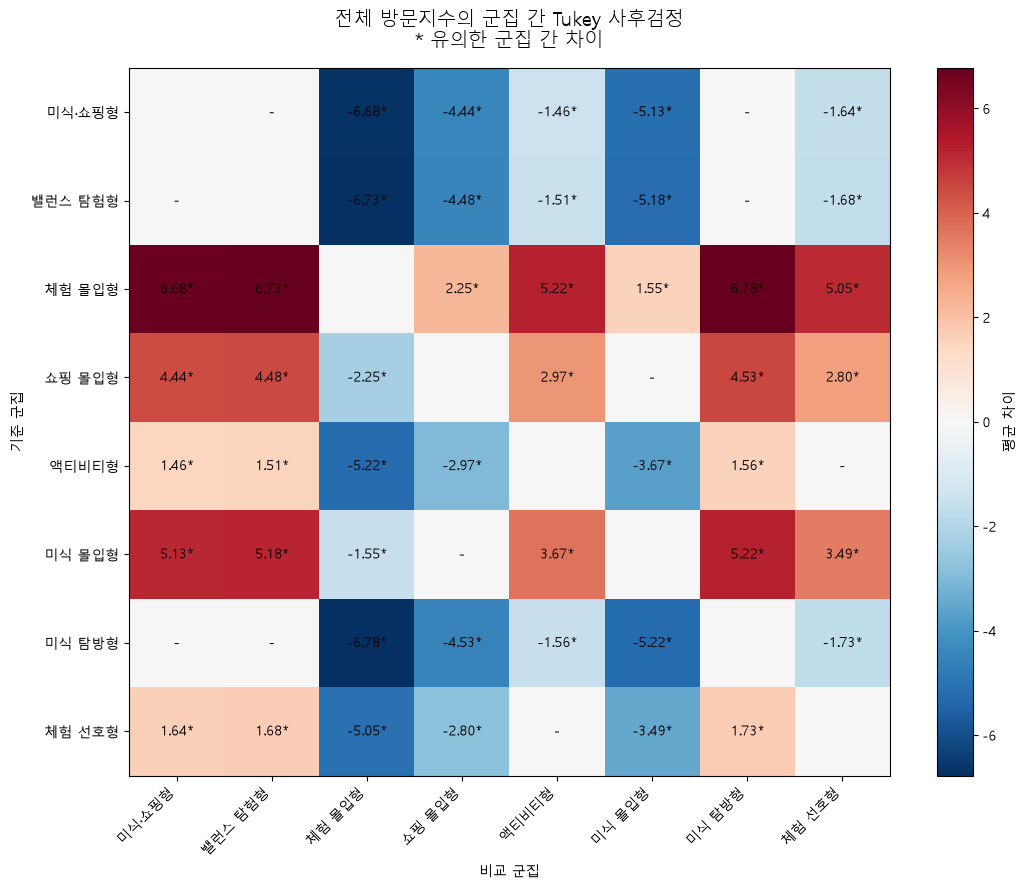

In [116]:
tukey_2 = plot_tukey_heatmap(
    cluster_full,
    "전체_방문지수",
    cluster_order=cluster_order,
    title="전체 방문지수의 군집 간 Tukey 사후검정"
)

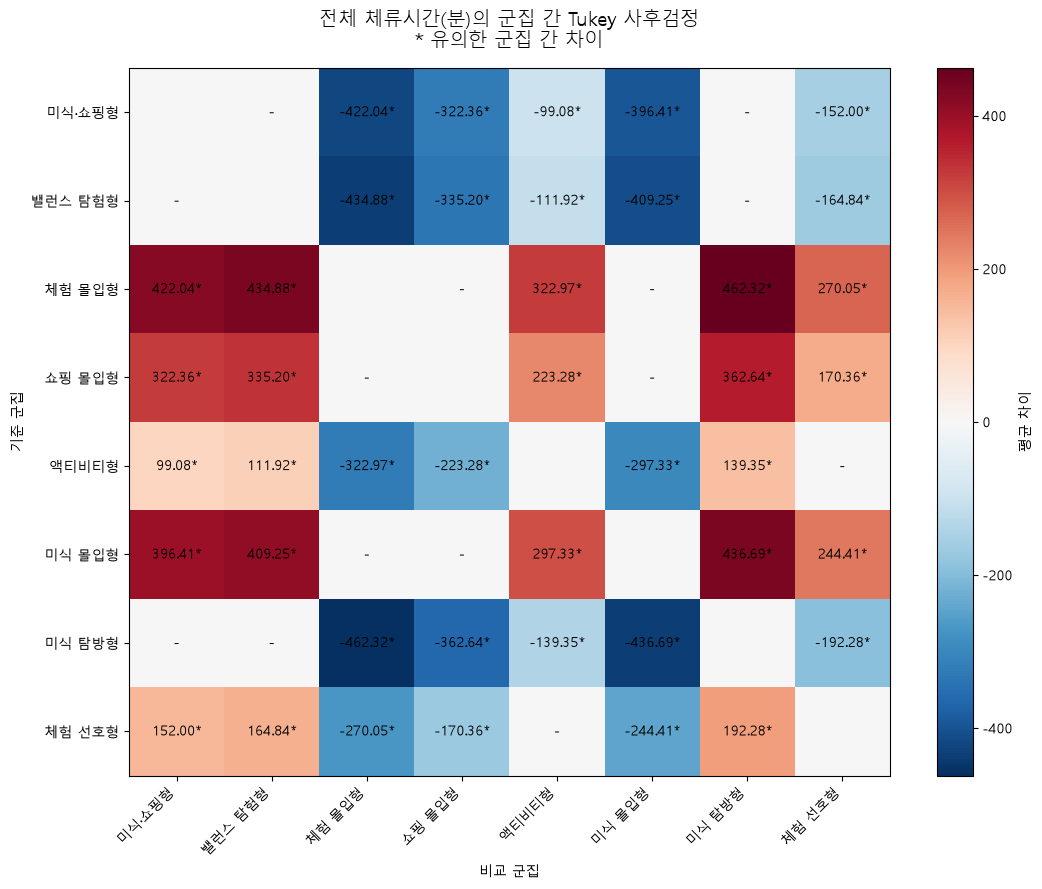

In [117]:
tukey_3 = plot_tukey_heatmap(
    cluster_full,
    "전체_체류시간_분",
    cluster_order=cluster_order,
    title="전체 체류시간(분)의 군집 간 Tukey 사후검정"
)

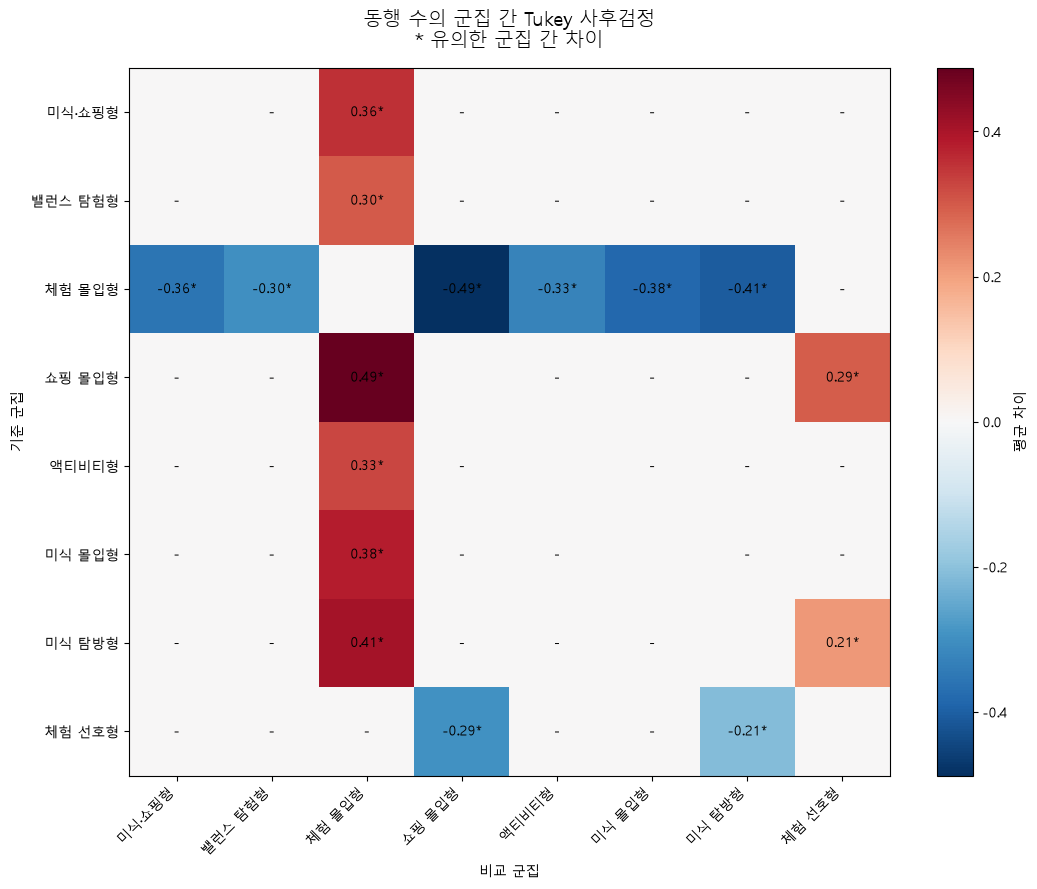

In [118]:
tukey_4 = plot_tukey_heatmap(
    cluster_full,
    "TRAVEL_COMPANIONS_NUM",
    cluster_order=cluster_order,
    title="동행 수의 군집 간 Tukey 사후검정"
)